# Analisis dan Prediksi Angka Harapan Hidup Negara untuk Mendukung SDG 3

**Nama:** Wa Ode Yurismawati  
**NIM:** E1E124080

## A. Identitas Proyek

**Deskripsi singkat.** Proyek ini menganalisis dan memprediksi *angka harapan hidup* (`life_expectancy`) negara-negara pada periode sekitar 2000–2021 untuk mendukung **SDG 3 (Good Health and Well-being)**.
Data berasal dari 4 file CSV hasil export database MySQL/phpMyAdmin:

| File | Sumber | Isi |
|---|---|---|
| `countries.csv` | Master negara | kode negara, nama negara, region, income group |
| `who_table.csv` | WHO | angka harapan hidup (`life_expectancy`) |
| `wdi_table.csv` | World Bank WDI | adult mortality, neonatal mortality, health expenditure |
| `owid_table.csv` | Our World in Data | death rate akibat cardiovascular, cancer, diabetes |

Kunci penghubung: `country_code` dan `year`. Target machine learning: `life_expectancy`.
Tidak ada dataset tambahan, dataset dummy, ataupun API yang dipakai: **hanya 4 CSV tersebut**.

## B. Business Questions

| No | Jenis | Pertanyaan |
|---|---|---|
| BQ1 | Basic / deskriptif | Bagaimana perkembangan rata-rata angka harapan hidup negara dari tahun ke tahun, dan bagaimana perbedaannya antar region dan income group? |
| BQ2 | Analitis 1 | Apakah *adult mortality* memiliki hubungan dengan angka harapan hidup, seberapa kuat, dan ke arah mana? |
| BQ3 | Analitis 2 | Bagaimana hubungan indikator kesehatan lain (neonatal mortality, health expenditure, cardiovascular death rate, cancer death rate, diabetes death rate) terhadap angka harapan hidup? |
| BQ4 | AI / Machine Learning | Seberapa baik model Random Forest Regressor memprediksi angka harapan hidup pada periode yang belum dilihat model (data uji temporal) berdasarkan indikator kesehatan dan mortalitas, dan fitur apa yang paling berpengaruh? |

# 1. Import All Packages

In [ ]:
import os, re, glob, warnings          # fungsi dasar Python (file, teks, peringatan)
import numpy as np                     # perhitungan angka
import pandas as pd                    # tabel data (DataFrame)

import matplotlib.pyplot as plt        # grafik dasar
import seaborn as sns                  # grafik statistik yang lebih rapi

from scipy import stats                # uji korelasi (Pearson, Spearman)

from sklearn.ensemble import RandomForestRegressor                       # model Random Forest
from sklearn.impute import SimpleImputer                                 # isi missing value
from sklearn.model_selection import GroupShuffleSplit                    # cadangan jika data hanya 1 tahun
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score   # evaluasi model

from IPython.display import display, Markdown   # menampilkan tabel & teks rapi di notebook

warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", 50)
pd.set_option("display.width", 200)
print("Semua library berhasil di-import.")

Semua library berhasil di-import.


# 2. Data Wrangling

## 2.1 Gathering Data

**Langkah 1:** upload keempat file CSV (`countries.csv`, `who_table.csv`, `wdi_table.csv`, `owid_table.csv`) sekaligus.

In [ ]:
from google.colab import files
uploaded = files.upload()
print("File yang diupload:", list(uploaded.keys()))

Saving countries.csv to countries.csv
Saving owid_table.csv to owid_table.csv
Saving wdi_table.csv to wdi_table.csv
Saving who_table.csv to who_table.csv
File yang diupload: ['countries.csv', 'owid_table.csv', 'wdi_table.csv', 'who_table.csv']


**Langkah 2:** baca keempat CSV menjadi DataFrame `df_countries`, `df_who`, `df_wdi`, `df_owid`.
Fungsi `baca_csv` hanya merapikan hal teknis: mencari file (walau namanya jadi `who_table (1).csv`), mencoba pemisah koma/titik-koma, membaca teks `NULL` sebagai kosong, dan menyeragamkan nama kolom menjadi huruf kecil tanpa spasi. **Isi datanya tidak diubah.**

In [ ]:
def baca_csv(nama):
    # 1) cari file: nama persis dulu, kalau tidak ada cari yang diawali nama itu (misal "who_table (1).csv")
    path = f"{nama}.csv"
    if not os.path.exists(path):
        cocok = sorted(glob.glob(f"{nama}*.csv"), key=os.path.getmtime, reverse=True)
        if not cocok:
            raise FileNotFoundError(f"File {nama}.csv tidak ditemukan. Jalankan ulang cell upload.")
        path = cocok[0]
    # 2) baca dengan pemisah koma; jika hasilnya hanya 1 kolom, coba titik-koma
    df = pd.read_csv(path, encoding="utf-8-sig", keep_default_na=False,
                     na_values=["", "NULL", "null", "NaN", "nan", "N/A"], low_memory=False)
    if df.shape[1] == 1:
        df = pd.read_csv(path, sep=";", encoding="utf-8-sig", keep_default_na=False,
                         na_values=["", "NULL", "null", "NaN", "nan", "N/A"], low_memory=False)
    # 3) seragamkan nama kolom: huruf kecil, spasi -> underscore
    df.columns = [re.sub(r"\s+", "_", str(c).strip().lower()) for c in df.columns]
    return df

def tampilkan_data(df, nama):
    print(f"===== {nama} =====")
    print("Jumlah baris x kolom:", df.shape)
    print("Nama kolom:", list(df.columns))
    print("\nTipe data:");  display(df.dtypes.to_frame("tipe"))
    print("5 data pertama:"); display(df.head())

df_countries = baca_csv("countries")
df_who       = baca_csv("who_table")
df_wdi       = baca_csv("wdi_table")
df_owid      = baca_csv("owid_table")
print("Keempat CSV berhasil dibaca.")

Keempat CSV berhasil dibaca.


**Langkah 3:** tampilkan isi setiap tabel (jumlah baris/kolom, nama kolom, tipe data, 5 data pertama). Satu cell untuk satu tabel.

In [ ]:
tampilkan_data(df_countries, "countries")

===== countries =====
Jumlah baris x kolom: (185, 3)
Nama kolom: ['country_code', 'country_name', 'region']

Tipe data:


,tipe
country_code,object
country_name,object
region,object


5 data pertama:


,country_code,country_name,region
0,AFG,Afghanistan,"Middle East, North Africa, Afghanistan & Pakistan"
1,AGO,Angola,Sub-Saharan Africa
2,ALB,Albania,Europe & Central Asia
3,ARE,United Arab Emirates,"Middle East, North Africa, Afghanistan & Pakistan"
4,ARG,Argentina,Latin America & Caribbean


In [ ]:
tampilkan_data(df_who, "who_table")

===== who_table =====
Jumlah baris x kolom: (12210, 7)
Nama kolom: ['id', 'country_code', 'year', 'sex', 'life_expectancy', 'low', 'high']

Tipe data:


,tipe
id,int64
country_code,object
year,int64
sex,object
life_expectancy,float64
low,float64
high,float64


5 data pertama:


,id,country_code,year,sex,life_expectancy,low,high
0,1,TGO,2016,Female,64.63,63.84,65.56
1,2,BLR,2007,Male,64.51,64.44,64.63
2,3,SOM,2005,Male,47.69,46.40,49.04
3,4,GAB,2000,Female,59.46,58.64,60.51
4,5,JAM,2006,Male,72.49,72.27,72.88


In [ ]:
tampilkan_data(df_wdi, "wdi_table")

===== wdi_table =====
Jumlah baris x kolom: (4070, 6)
Nama kolom: ['id', 'country_code', 'year', 'adult_mortality', 'neonatal_mortality', 'health_expenditure']

Tipe data:


,tipe
id,int64
country_code,object
year,int64
adult_mortality,float64
neonatal_mortality,float64
health_expenditure,float64


5 data pertama:


,id,country_code,year,adult_mortality,neonatal_mortality,health_expenditure
0,1,AFG,2000,326.60,62.2,NaN
1,2,AFG,2001,321.11,60.9,NaN
2,3,AFG,2002,309.64,59.6,16.71
3,4,AFG,2003,298.46,58.2,17.75
4,5,AFG,2004,290.78,56.8,21.42


In [ ]:
tampilkan_data(df_owid, "owid_table")

===== owid_table =====
Jumlah baris x kolom: (4026, 6)
Nama kolom: ['id', 'country_code', 'year', 'cardiovascular_death_rate', 'cancer_death_rate', 'diabetes_death_rate']

Tipe data:


,tipe
id,int64
country_code,object
year,int64
cardiovascular_death_rate,float64
cancer_death_rate,float64
diabetes_death_rate,float64


5 data pertama:


,id,country_code,year,cardiovascular_death_rate,cancer_death_rate,diabetes_death_rate
0,1,AFG,2000,218.71,43.39,9.64
1,2,AFG,2001,220.08,42.96,9.91
2,3,AFG,2002,215.84,41.94,10.25
3,4,AFG,2003,213.80,42.62,10.67
4,5,AFG,2004,211.13,43.29,11.04


**Catatan:** nama kolom di atas adalah nama **asli** dari CSV Anda. Kode setelah ini mendeteksi kolom berdasarkan nama tersebut dan selalu menampilkan hasil deteksinya.

## 2.2 Assessing Data (sebelum cleaning)

Pada tahap ini data **belum diubah**. Fungsi `assess_data` menampilkan 14 pemeriksaan untuk satu tabel:

1. `shape` 2. `head()` 3. `tail()` 4. `info()` 5. nama kolom 6. tipe data 7. jumlah missing 8. persentase missing 9. duplicate baris 10. statistik deskriptif 11. nilai unik kolom kategorikal 12. konsistensi `country_code` 13. rentang tahun 14. nilai tidak masuk akal

Setelah fungsi dibuat, tiap tabel dijalankan di **cell terpisah**.

In [ ]:
KOLOM_KUNCI = ["country_code", "year", "sex", "gender", "dim1", "indicator_code", "indicator", "series_code"]

def assess_data(df, nama):
    print("=" * 90); print(f"ASSESSMENT: {nama}"); print("=" * 90)
    print("1. Shape:", df.shape)
    print("\n2. head():");  display(df.head())
    print("3. tail():");    display(df.tail())
    print("4. info():");    df.info()
    print("\n5. Nama kolom:", list(df.columns))
    print("\n6. Tipe data:"); display(df.dtypes.to_frame("tipe"))

    miss = df.isna().sum()
    print("7-8. Missing value (jumlah dan persen):")
    display(pd.DataFrame({"jumlah": miss, "persen": (miss / max(len(df), 1) * 100).round(2)}))

    dup_baris = int(df.duplicated().sum())
    kunci = [c for c in KOLOM_KUNCI if c in df.columns]
    dup_kunci = int(df.duplicated(subset=kunci).sum()) if kunci else 0
    print(f"9. Duplicate baris identik: {dup_baris}")
    print(f"   Duplicate berdasarkan kunci {kunci}: {dup_kunci}")

    angka = df.select_dtypes(include=np.number)
    if angka.shape[1] > 0:
        print("\n10. Statistik deskriptif (kolom numerik):"); display(angka.describe().T)

    print("11. Kolom kategorikal:")
    for c in df.select_dtypes(exclude=np.number).columns:
        n = df[c].nunique()
        contoh = sorted(df[c].dropna().astype(str).unique().tolist())[:12] if n <= 15 else df[c].dropna().astype(str).unique()[:5].tolist()
        print(f"   - {c}: {n} nilai unik -> {contoh}")

    if "country_code" in df.columns:
        kode = df["country_code"].dropna().astype(str)
        print(f"\n12. country_code: {kode.nunique()} kode unik, panjang kode {sorted(kode.str.len().unique().tolist())}, "
              f"kosong {int(df['country_code'].isna().sum())}, "
              f"ada spasi/huruf kecil {int((kode != kode.str.strip().str.upper()).sum())}")
    if "year" in df.columns:
        th = pd.to_numeric(df["year"], errors="coerce")
        print(f"13. Rentang tahun: {th.min()} - {th.max()} | tahun tidak valid/kosong: {int(th.isna().sum())} | tahun unik: {th.nunique()}")

    print("14. Nilai tidak masuk akal:")
    ada = False
    for c in angka.columns:
        if c == "year":
            continue
        neg = int((df[c] < 0).sum())
        if neg:
            print(f"   - {c}: {neg} nilai negatif"); ada = True
        if "life_expect" in c:
            buruk = int(((df[c] <= 0) | (df[c] > 120)).sum())
            if buruk:
                print(f"   - {c}: {buruk} nilai di luar 0-120 tahun"); ada = True
    if not ada:
        print("   tidak ditemukan.")

    return {"rows": len(df), "missing": int(miss.sum()), "dup_baris": dup_baris, "dup_kunci": dup_kunci}

hasil_sebelum = {}

**Assessment tabel `countries`**

In [ ]:
hasil_sebelum["countries"] = assess_data(df_countries, "countries")

ASSESSMENT: countries
1. Shape: (185, 3)

2. head():


,country_code,country_name,region
0,AFG,Afghanistan,"Middle East, North Africa, Afghanistan & Pakistan"
1,AGO,Angola,Sub-Saharan Africa
2,ALB,Albania,Europe & Central Asia
3,ARE,United Arab Emirates,"Middle East, North Africa, Afghanistan & Pakistan"
4,ARG,Argentina,Latin America & Caribbean


3. tail():


,country_code,country_name,region
180,WSM,Samoa,East Asia & Pacific
181,YEM,"Yemen, Rep.","Middle East, North Africa, Afghanistan & Pakistan"
182,ZAF,South Africa,Sub-Saharan Africa
183,ZMB,Zambia,Sub-Saharan Africa
184,ZWE,Zimbabwe,Sub-Saharan Africa


4. info():
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 185 entries, 0 to 184
Data columns (total 3 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   country_code  185 non-null    object
 1   country_name  185 non-null    object
 2   region        185 non-null    object
dtypes: object(3)
memory usage: 4.5+ KB

5. Nama kolom: ['country_code', 'country_name', 'region']

6. Tipe data:


,tipe
country_code,object
country_name,object
region,object


7-8. Missing value (jumlah dan persen):


,jumlah,persen
country_code,0,0.0
country_name,0,0.0
region,0,0.0


9. Duplicate baris identik: 0
   Duplicate berdasarkan kunci ['country_code']: 0
11. Kolom kategorikal:
   - country_code: 185 nilai unik -> ['AFG', 'AGO', 'ALB', 'ARE', 'ARG']
   - country_name: 185 nilai unik -> ['Afghanistan', 'Angola', 'Albania', 'United Arab Emirates', 'Argentina']
   - region: 7 nilai unik -> ['East Asia & Pacific', 'Europe & Central Asia', 'Latin America & Caribbean', 'Middle East, North Africa, Afghanistan & Pakistan', 'North America', 'South Asia', 'Sub-Saharan Africa']

12. country_code: 185 kode unik, panjang kode [3], kosong 0, ada spasi/huruf kecil 0
14. Nilai tidak masuk akal:
   tidak ditemukan.


**Assessment tabel `who_table`**

In [ ]:
hasil_sebelum["who"] = assess_data(df_who, "who_table")

ASSESSMENT: who_table
1. Shape: (12210, 7)

2. head():


,id,country_code,year,sex,life_expectancy,low,high
0,1,TGO,2016,Female,64.63,63.84,65.56
1,2,BLR,2007,Male,64.51,64.44,64.63
2,3,SOM,2005,Male,47.69,46.40,49.04
3,4,GAB,2000,Female,59.46,58.64,60.51
4,5,JAM,2006,Male,72.49,72.27,72.88


3. tail():


,id,country_code,year,sex,life_expectancy,low,high
12205,12206,MLT,2010,Both sexes,80.48,80.37,80.67
12206,12207,BLR,2020,Both sexes,73.01,72.73,73.45
12207,12208,CAF,2021,Female,55.38,54.11,56.58
12208,12209,BGD,2018,Both sexes,73.67,73.04,74.48
12209,12210,UGA,2007,Female,59.01,58.09,59.96


4. info():
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12210 entries, 0 to 12209
Data columns (total 7 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   id               12210 non-null  int64  
 1   country_code     12210 non-null  object 
 2   year             12210 non-null  int64  
 3   sex              12210 non-null  object 
 4   life_expectancy  12210 non-null  float64
 5   low              12190 non-null  float64
 6   high             12190 non-null  float64
dtypes: float64(3), int64(2), object(2)
memory usage: 667.9+ KB

5. Nama kolom: ['id', 'country_code', 'year', 'sex', 'life_expectancy', 'low', 'high']

6. Tipe data:


...

7-8. Missing value (jumlah dan persen):


,jumlah,persen
id,0,0.00
country_code,0,0.00
year,0,0.00
sex,0,0.00
life_expectancy,0,0.00
low,20,0.16
high,20,0.16


9. Duplicate baris identik: 0
   Duplicate berdasarkan kunci ['country_code', 'year', 'sex']: 0

10. Statistik deskriptif (kolom numerik):


,count,mean,std,min,25%,50%,75%,max
id,12210.0,6105.500000,3524.867728,1.00,3053.2500,6105.50,9157.7500,12210.00
year,12210.0,2010.500000,6.344549,2000.00,2005.0000,2010.50,2016.0000,2021.00
life_expectancy,12210.0,70.174928,8.899692,36.60,64.1900,71.87,77.0875,87.37
low,12190.0,69.706750,9.198800,36.00,63.4200,71.45,76.8400,87.32
high,12190.0,70.680702,8.587786,37.36,64.9725,72.29,77.3400,87.42


11. Kolom kategorikal:
   - country_code: 185 nilai unik -> ['TGO', 'BLR', 'SOM', 'GAB', 'JAM']
   - sex: 3 nilai unik -> ['Both sexes', 'Female', 'Male']

12. country_code: 185 kode unik, panjang kode [3], kosong 0, ada spasi/huruf kecil 0
13. Rentang tahun: 2000 - 2021 | tahun tidak valid/kosong: 0 | tahun unik: 22
14. Nilai tidak masuk akal:
   tidak ditemukan.


**Assessment tabel `wdi_table`**

In [ ]:
hasil_sebelum["wdi"] = assess_data(df_wdi, "wdi_table")

ASSESSMENT: wdi_table
1. Shape: (4070, 6)

2. head():


,id,country_code,year,adult_mortality,neonatal_mortality,health_expenditure
0,1,AFG,2000,326.60,62.2,NaN
1,2,AFG,2001,321.11,60.9,NaN
2,3,AFG,2002,309.64,59.6,16.71
3,4,AFG,2003,298.46,58.2,17.75
4,5,AFG,2004,290.78,56.8,21.42


3. tail():


,id,country_code,year,adult_mortality,neonatal_mortality,health_expenditure
4065,4066,ZWE,2017,364.28,28.6,91.87
4066,4067,ZWE,2018,352.67,29.4,114.77
4067,4068,ZWE,2019,351.44,30.3,55.11
4068,4069,ZWE,2020,341.05,31.3,51.14
4069,4070,ZWE,2021,382.02,32.2,60.90


4. info():
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4070 entries, 0 to 4069
Data columns (total 6 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   id                  4070 non-null   int64  
 1   country_code        4070 non-null   object 
 2   year                4070 non-null   int64  
 3   adult_mortality     4063 non-null   float64
 4   neonatal_mortality  4048 non-null   float64
 5   health_expenditure  3948 non-null   float64
dtypes: float64(3), int64(2), object(1)
memory usage: 190.9+ KB

5. Nama kolom: ['id', 'country_code', 'year', 'adult_mortality', 'neonatal_mortality', 'health_expenditure']

6. Tipe data:


...

7-8. Missing value (jumlah dan persen):


,jumlah,persen
id,0,0.00
country_code,0,0.00
year,0,0.00
adult_mortality,7,0.17
neonatal_mortality,22,0.54
health_expenditure,122,3.00


9. Duplicate baris identik: 0
   Duplicate berdasarkan kunci ['country_code', 'year']: 0

10. Statistik deskriptif (kolom numerik):


,count,mean,std,min,25%,50%,75%,max
id,4070.0,2035.500000,1175.052127,1.00,1018.250,2035.50,3052.7500,4070.00
year,4070.0,2010.500000,6.345068,2000.00,2005.000,2010.50,2016.0000,2021.00
adult_mortality,4063.0,188.111519,110.169388,29.35,106.475,167.05,249.4550,918.31
neonatal_mortality,4048.0,15.534165,12.403417,0.80,4.900,11.60,24.3000,62.20
health_expenditure,3948.0,881.182492,1606.330540,4.18,59.500,231.64,775.3575,12080.07


11. Kolom kategorikal:
   - country_code: 185 nilai unik -> ['AFG', 'AGO', 'ALB', 'ARE', 'ARG']

12. country_code: 185 kode unik, panjang kode [3], kosong 0, ada spasi/huruf kecil 0
13. Rentang tahun: 2000 - 2021 | tahun tidak valid/kosong: 0 | tahun unik: 22
14. Nilai tidak masuk akal:
   tidak ditemukan.


**Assessment tabel `owid_table`**

In [ ]:
hasil_sebelum["owid"] = assess_data(df_owid, "owid_table")

ASSESSMENT: owid_table
1. Shape: (4026, 6)

2. head():


,id,country_code,year,cardiovascular_death_rate,cancer_death_rate,diabetes_death_rate
0,1,AFG,2000,218.71,43.39,9.64
1,2,AFG,2001,220.08,42.96,9.91
2,3,AFG,2002,215.84,41.94,10.25
3,4,AFG,2003,213.80,42.62,10.67
4,5,AFG,2004,211.13,43.29,11.04


3. tail():


,id,country_code,year,cardiovascular_death_rate,cancer_death_rate,diabetes_death_rate
4021,4022,ZWE,2017,143.50,107.99,26.79
4022,4023,ZWE,2018,146.01,109.05,27.26
4023,4024,ZWE,2019,141.90,109.58,26.65
4024,4025,ZWE,2020,152.05,96.53,28.55
4025,4026,ZWE,2021,145.38,76.23,27.89


4. info():
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4026 entries, 0 to 4025
Data columns (total 6 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   id                         4026 non-null   int64  
 1   country_code               4026 non-null   object 
 2   year                       4026 non-null   int64  
 3   cardiovascular_death_rate  4026 non-null   float64
 4   cancer_death_rate          4026 non-null   float64
 5   diabetes_death_rate        4026 non-null   float64
dtypes: float64(3), int64(2), object(1)
memory usage: 188.8+ KB

5. Nama kolom: ['id', 'country_code', 'year', 'cardiovascular_death_rate', 'cancer_death_rate', 'diabetes_death_rate']

6. Tipe data:


...

7-8. Missing value (jumlah dan persen):


,jumlah,persen
id,0,0.0
country_code,0,0.0
year,0,0.0
cardiovascular_death_rate,0,0.0
cancer_death_rate,0,0.0
diabetes_death_rate,0,0.0


9. Duplicate baris identik: 0
   Duplicate berdasarkan kunci ['country_code', 'year']: 0

10. Statistik deskriptif (kolom numerik):


,count,mean,std,min,25%,50%,75%,max
id,4026.0,2013.500000,1162.350420,1.00,1007.2500,2013.500,3019.7500,4026.00
year,4026.0,2010.500000,6.345077,2000.00,2005.0000,2010.500,2016.0000,2021.00
cardiovascular_death_rate,4026.0,241.236831,188.019290,36.53,123.4200,175.270,275.5075,1267.66
cancer_death_rate,4026.0,117.640425,82.475809,17.31,53.4925,80.435,181.3800,355.56
diabetes_death_rate,4026.0,23.584439,21.138059,1.53,11.9325,17.200,26.9050,181.65


11. Kolom kategorikal:
   - country_code: 183 nilai unik -> ['AFG', 'AGO', 'ALB', 'ARE', 'ARG']

12. country_code: 183 kode unik, panjang kode [3], kosong 0, ada spasi/huruf kecil 0
13. Rentang tahun: 2000 - 2021 | tahun tidak valid/kosong: 0 | tahun unik: 22
14. Nilai tidak masuk akal:
   tidak ditemukan.


### Ringkasan Masalah Data

Tabel ini dibuat **otomatis dari hasil assessment**, jadi hanya berisi masalah yang benar-benar terdeteksi.

In [ ]:
data_mentah = {"countries": df_countries, "who": df_who, "wdi": df_wdi, "owid": df_owid}
baris = []
for nama, d in data_mentah.items():
    h = hasil_sebelum[nama]
    miss = d.isna().sum(); miss = miss[miss > 0]
    if len(miss):
        top = ", ".join(f"{c} ({n})" for c, n in miss.sort_values(ascending=False).head(4).items())
        baris.append([nama, f"Missing value di {len(miss)} kolom: {top}", "Tidak dihapus; diisi median (hanya dari data latih) saat tahap ML"])
    if h["dup_baris"] > 0:
        baris.append([nama, f"Duplicate baris identik: {h['dup_baris']}", "Hapus duplicate"])
    if h["dup_kunci"] > h["dup_baris"]:
        baris.append([nama, f"Kunci (country_code, year, ...) ganda: {h['dup_kunci']}", "Digabung dengan rata-rata"])
    for c in d.columns:
        if not pd.api.types.is_numeric_dtype(d[c]) and d[c].notna().any():
            if pd.to_numeric(d[c], errors="coerce").notna().sum() / d[c].notna().sum() >= 0.95:
                baris.append([nama, f"Kolom '{c}' bertipe teks tetapi isinya angka", "Ubah ke numerik"])
    if "country_code" in d.columns:
        kode = d["country_code"].dropna().astype(str)
        if (kode != kode.str.strip().str.upper()).any():
            baris.append([nama, "country_code tidak konsisten (spasi/huruf kecil)", "Strip dan huruf besar"])
    if "year" in d.columns and not pd.api.types.is_integer_dtype(d["year"]):
        baris.append([nama, f"Kolom year bertipe {d['year'].dtype}", "Ubah ke integer"])
if not baris:
    baris.append(["(semua)", "Tidak ada masalah terdeteksi", "-"])
with pd.option_context("display.max_colwidth", 200):
    display(pd.DataFrame(baris, columns=["Dataset", "Masalah (terdeteksi)", "Penanganan"]))

,Dataset,Masalah (terdeteksi),Penanganan
0,who,"Missing value di 2 kolom: low (20), high (20)",Tidak dihapus; diisi median (hanya dari data latih) saat tahap ML
1,wdi,"Missing value di 3 kolom: health_expenditure (122), neonatal_mortality (22), adult_mortality (7)",Tidak dihapus; diisi median (hanya dari data latih) saat tahap ML


## 2.3 Data Cleaning

Cleaning hanya dilakukan untuk masalah yang ditemukan di 2.2, dan **tidak menghapus data secara sembarangan**:

| Langkah | Alasan |
|---|---|
| Hapus kolom teknis database (`id`, `created_at`, dll. bila ada) | Tidak berguna untuk analisis |
| `country_code`: strip + huruf besar; baris tanpa kode dihapus | Kunci join harus konsisten |
| `year` dijadikan integer; baris tahun tidak valid dihapus | Kunci join dan dasar split temporal |
| Kolom teks yang isinya angka diubah ke numerik | Agar bisa dihitung |
| Nilai mustahil (life expectancy di luar 0–120, nilai negatif) diubah jadi *missing* | Terbukti error, tetapi barisnya tidak dibuang |
| Hapus duplicate baris identik | Menghindari data ganda |
| Kunci ganda (`country_code`+`year`) digabung dengan rata-rata | Satu baris per negara-tahun |
| **Missing value tidak dihapus di sini** | Diisi saat tahap ML hanya dari data latih (mencegah leakage) |

Fungsi `clean_data` dibuat sekali, lalu dipakai di cell terpisah untuk tiap tabel.

In [ ]:
def clean_data(df, master=False):
    d = df.copy()
    log = []

    # 1) buang kolom teknis database
    teknis = [c for c in d.columns if c in ["id", "created_at", "updated_at"]]
    if teknis:
        d = d.drop(columns=teknis); log.append(f"Kolom teknis dihapus: {teknis}")

    # 2) country_code: rapikan, hapus baris tanpa kode
    d["country_code"] = d["country_code"].astype(str).str.strip().str.upper().replace({"": np.nan, "NAN": np.nan})
    n = len(d); d = d.dropna(subset=["country_code"])
    if n != len(d): log.append(f"Baris tanpa country_code dihapus: {n - len(d)}")

    # 3) year -> integer (hanya untuk tabel yang punya year)
    if not master:
        d["year"] = pd.to_numeric(d["year"], errors="coerce")
        n = len(d); d = d[d["year"].between(1900, 2100)]
        d["year"] = d["year"].astype(int)
        if n != len(d): log.append(f"Baris dengan year tidak valid dihapus: {n - len(d)}")

    # 4) kolom teks yang isinya angka -> numerik
    kolom_dimensi = ["sex", "gender", "dim1", "indicator", "indicator_code", "indicator_name", "series", "series_code", "metric"]
    for c in d.columns:
        if c in ["country_code", "year"] + kolom_dimensi or pd.api.types.is_numeric_dtype(d[c]):
            continue
        angka = pd.to_numeric(d[c], errors="coerce")
        if d[c].notna().sum() > 0 and angka.notna().sum() / d[c].notna().sum() >= 0.95:
            d[c] = angka; log.append(f"Kolom '{c}' diubah ke numerik")

    # 5) nilai mustahil -> missing (life expectancy 0-120, indikator lain tidak boleh negatif)
    for c in d.columns:
        if c == "year" or not pd.api.types.is_numeric_dtype(d[c]):
            continue
        buruk = ((d[c] <= 0) | (d[c] > 120)) if "life_expect" in c else (d[c] < 0)
        if buruk.sum() > 0:
            d.loc[buruk, c] = np.nan; log.append(f"Kolom '{c}': {int(buruk.sum())} nilai tidak valid -> missing")

    # 6) hapus duplicate baris identik
    n = len(d); d = d.drop_duplicates()
    if n != len(d): log.append(f"Duplicate baris dihapus: {n - len(d)}")

    # 7) kunci ganda -> digabung rata-rata (agar join tidak menggandakan baris)
    kunci = ["country_code"] if master else [c for c in ["country_code", "year"] + kolom_dimensi if c in d.columns]
    if d.duplicated(subset=kunci).any():
        n = len(d)
        if master:
            d = d.drop_duplicates(subset=kunci)
        else:
            urutan = list(d.columns)
            agg = {c: ("mean" if pd.api.types.is_numeric_dtype(d[c]) else "first") for c in d.columns if c not in kunci}
            d = d.groupby(kunci, as_index=False, sort=False).agg(agg)[urutan] if agg else d.drop_duplicates(subset=kunci)
        log.append(f"Kunci ganda digabung: {n} -> {len(d)} baris")

    return d.reset_index(drop=True), log

def tampilkan_log(nama, sebelum, sesudah, log):
    print(f"[{nama}] ukuran: {sebelum.shape} -> {sesudah.shape}")
    for baris in (log or ["Tidak ada perubahan yang diperlukan"]):
        print("   -", baris)

**Cleaning `countries`**

In [ ]:
df_countries_bersih, log = clean_data(df_countries, master=True)
tampilkan_log("countries", df_countries, df_countries_bersih, log)

[countries] ukuran: (185, 3) -> (185, 3)
   - Tidak ada perubahan yang diperlukan


**Cleaning `who_table`**

In [ ]:
df_who_bersih, log = clean_data(df_who)
tampilkan_log("who", df_who, df_who_bersih, log)

[who] ukuran: (12210, 7) -> (12210, 6)
   - Kolom teknis dihapus: ['id']


**Cleaning `wdi_table`**

In [ ]:
df_wdi_bersih, log = clean_data(df_wdi)
tampilkan_log("wdi", df_wdi, df_wdi_bersih, log)

[wdi] ukuran: (4070, 6) -> (4070, 5)
   - Kolom teknis dihapus: ['id']


**Cleaning `owid_table`**

In [ ]:
df_owid_bersih, log = clean_data(df_owid)
tampilkan_log("owid", df_owid, df_owid_bersih, log)

[owid] ukuran: (4026, 6) -> (4026, 5)
   - Kolom teknis dihapus: ['id']


## 2.4 Assessing Data Setelah Cleaning

Fungsi `assess_data` yang sama dipakai lagi, satu cell per tabel, lalu hasilnya dibandingkan dengan kondisi sebelum cleaning.

In [ ]:
hasil_sesudah = {}
hasil_sesudah["countries"] = assess_data(df_countries_bersih, "countries (setelah cleaning)")

ASSESSMENT: countries (setelah cleaning)
1. Shape: (185, 3)

2. head():


,country_code,country_name,region
0,AFG,Afghanistan,"Middle East, North Africa, Afghanistan & Pakistan"
1,AGO,Angola,Sub-Saharan Africa
2,ALB,Albania,Europe & Central Asia
3,ARE,United Arab Emirates,"Middle East, North Africa, Afghanistan & Pakistan"
4,ARG,Argentina,Latin America & Caribbean


3. tail():


,country_code,country_name,region
180,WSM,Samoa,East Asia & Pacific
181,YEM,"Yemen, Rep.","Middle East, North Africa, Afghanistan & Pakistan"
182,ZAF,South Africa,Sub-Saharan Africa
183,ZMB,Zambia,Sub-Saharan Africa
184,ZWE,Zimbabwe,Sub-Saharan Africa


4. info():
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 185 entries, 0 to 184
Data columns (total 3 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   country_code  185 non-null    object
 1   country_name  185 non-null    object
 2   region        185 non-null    object
dtypes: object(3)
memory usage: 4.5+ KB

5. Nama kolom: ['country_code', 'country_name', 'region']

6. Tipe data:


,tipe
country_code,object
country_name,object
region,object


7-8. Missing value (jumlah dan persen):


,jumlah,persen
country_code,0,0.0
country_name,0,0.0
region,0,0.0


9. Duplicate baris identik: 0
   Duplicate berdasarkan kunci ['country_code']: 0
11. Kolom kategorikal:
   - country_code: 185 nilai unik -> ['AFG', 'AGO', 'ALB', 'ARE', 'ARG']
   - country_name: 185 nilai unik -> ['Afghanistan', 'Angola', 'Albania', 'United Arab Emirates', 'Argentina']
   - region: 7 nilai unik -> ['East Asia & Pacific', 'Europe & Central Asia', 'Latin America & Caribbean', 'Middle East, North Africa, Afghanistan & Pakistan', 'North America', 'South Asia', 'Sub-Saharan Africa']

12. country_code: 185 kode unik, panjang kode [3], kosong 0, ada spasi/huruf kecil 0
14. Nilai tidak masuk akal:
   tidak ditemukan.


In [ ]:
hasil_sesudah["who"] = assess_data(df_who_bersih, "who_table (setelah cleaning)")

ASSESSMENT: who_table (setelah cleaning)
1. Shape: (12210, 6)

2. head():


,country_code,year,sex,life_expectancy,low,high
0,TGO,2016,Female,64.63,63.84,65.56
1,BLR,2007,Male,64.51,64.44,64.63
2,SOM,2005,Male,47.69,46.40,49.04
3,GAB,2000,Female,59.46,58.64,60.51
4,JAM,2006,Male,72.49,72.27,72.88


3. tail():


,country_code,year,sex,life_expectancy,low,high
12205,MLT,2010,Both sexes,80.48,80.37,80.67
12206,BLR,2020,Both sexes,73.01,72.73,73.45
12207,CAF,2021,Female,55.38,54.11,56.58
12208,BGD,2018,Both sexes,73.67,73.04,74.48
12209,UGA,2007,Female,59.01,58.09,59.96


4. info():
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12210 entries, 0 to 12209
Data columns (total 6 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   country_code     12210 non-null  object 
 1   year             12210 non-null  int64  
 2   sex              12210 non-null  object 
 3   life_expectancy  12210 non-null  float64
 4   low              12190 non-null  float64
 5   high             12190 non-null  float64
dtypes: float64(3), int64(1), object(2)
memory usage: 572.5+ KB

5. Nama kolom: ['country_code', 'year', 'sex', 'life_expectancy', 'low', 'high']

6. Tipe data:


...

7-8. Missing value (jumlah dan persen):


,jumlah,persen
country_code,0,0.00
year,0,0.00
sex,0,0.00
life_expectancy,0,0.00
low,20,0.16
high,20,0.16


9. Duplicate baris identik: 0
   Duplicate berdasarkan kunci ['country_code', 'year', 'sex']: 0

10. Statistik deskriptif (kolom numerik):


,count,mean,std,min,25%,50%,75%,max
year,12210.0,2010.500000,6.344549,2000.00,2005.0000,2010.50,2016.0000,2021.00
life_expectancy,12210.0,70.174928,8.899692,36.60,64.1900,71.87,77.0875,87.37
low,12190.0,69.706750,9.198800,36.00,63.4200,71.45,76.8400,87.32
high,12190.0,70.680702,8.587786,37.36,64.9725,72.29,77.3400,87.42


11. Kolom kategorikal:
   - country_code: 185 nilai unik -> ['TGO', 'BLR', 'SOM', 'GAB', 'JAM']
   - sex: 3 nilai unik -> ['Both sexes', 'Female', 'Male']

12. country_code: 185 kode unik, panjang kode [3], kosong 0, ada spasi/huruf kecil 0
13. Rentang tahun: 2000 - 2021 | tahun tidak valid/kosong: 0 | tahun unik: 22
14. Nilai tidak masuk akal:
   tidak ditemukan.


In [ ]:
hasil_sesudah["wdi"] = assess_data(df_wdi_bersih, "wdi_table (setelah cleaning)")

ASSESSMENT: wdi_table (setelah cleaning)
1. Shape: (4070, 5)

2. head():


,country_code,year,adult_mortality,neonatal_mortality,health_expenditure
0,AFG,2000,326.60,62.2,NaN
1,AFG,2001,321.11,60.9,NaN
2,AFG,2002,309.64,59.6,16.71
3,AFG,2003,298.46,58.2,17.75
4,AFG,2004,290.78,56.8,21.42


3. tail():


,country_code,year,adult_mortality,neonatal_mortality,health_expenditure
4065,ZWE,2017,364.28,28.6,91.87
4066,ZWE,2018,352.67,29.4,114.77
4067,ZWE,2019,351.44,30.3,55.11
4068,ZWE,2020,341.05,31.3,51.14
4069,ZWE,2021,382.02,32.2,60.90


4. info():
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4070 entries, 0 to 4069
Data columns (total 5 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   country_code        4070 non-null   object 
 1   year                4070 non-null   int64  
 2   adult_mortality     4063 non-null   float64
 3   neonatal_mortality  4048 non-null   float64
 4   health_expenditure  3948 non-null   float64
dtypes: float64(3), int64(1), object(1)
memory usage: 159.1+ KB

5. Nama kolom: ['country_code', 'year', 'adult_mortality', 'neonatal_mortality', 'health_expenditure']

6. Tipe data:


...

7-8. Missing value (jumlah dan persen):


,jumlah,persen
country_code,0,0.00
year,0,0.00
adult_mortality,7,0.17
neonatal_mortality,22,0.54
health_expenditure,122,3.00


9. Duplicate baris identik: 0
   Duplicate berdasarkan kunci ['country_code', 'year']: 0

10. Statistik deskriptif (kolom numerik):


,count,mean,std,min,25%,50%,75%,max
year,4070.0,2010.500000,6.345068,2000.00,2005.000,2010.50,2016.0000,2021.00
adult_mortality,4063.0,188.111519,110.169388,29.35,106.475,167.05,249.4550,918.31
neonatal_mortality,4048.0,15.534165,12.403417,0.80,4.900,11.60,24.3000,62.20
health_expenditure,3948.0,881.182492,1606.330540,4.18,59.500,231.64,775.3575,12080.07


11. Kolom kategorikal:
   - country_code: 185 nilai unik -> ['AFG', 'AGO', 'ALB', 'ARE', 'ARG']

12. country_code: 185 kode unik, panjang kode [3], kosong 0, ada spasi/huruf kecil 0
13. Rentang tahun: 2000 - 2021 | tahun tidak valid/kosong: 0 | tahun unik: 22
14. Nilai tidak masuk akal:
   tidak ditemukan.


In [ ]:
hasil_sesudah["owid"] = assess_data(df_owid_bersih, "owid_table (setelah cleaning)")

ASSESSMENT: owid_table (setelah cleaning)
1. Shape: (4026, 5)

2. head():


,country_code,year,cardiovascular_death_rate,cancer_death_rate,diabetes_death_rate
0,AFG,2000,218.71,43.39,9.64
1,AFG,2001,220.08,42.96,9.91
2,AFG,2002,215.84,41.94,10.25
3,AFG,2003,213.80,42.62,10.67
4,AFG,2004,211.13,43.29,11.04


3. tail():


,country_code,year,cardiovascular_death_rate,cancer_death_rate,diabetes_death_rate
4021,ZWE,2017,143.50,107.99,26.79
4022,ZWE,2018,146.01,109.05,27.26
4023,ZWE,2019,141.90,109.58,26.65
4024,ZWE,2020,152.05,96.53,28.55
4025,ZWE,2021,145.38,76.23,27.89


4. info():
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4026 entries, 0 to 4025
Data columns (total 5 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   country_code               4026 non-null   object 
 1   year                       4026 non-null   int64  
 2   cardiovascular_death_rate  4026 non-null   float64
 3   cancer_death_rate          4026 non-null   float64
 4   diabetes_death_rate        4026 non-null   float64
dtypes: float64(3), int64(1), object(1)
memory usage: 157.4+ KB

5. Nama kolom: ['country_code', 'year', 'cardiovascular_death_rate', 'cancer_death_rate', 'diabetes_death_rate']

6. Tipe data:


...

7-8. Missing value (jumlah dan persen):


,jumlah,persen
country_code,0,0.0
year,0,0.0
cardiovascular_death_rate,0,0.0
cancer_death_rate,0,0.0
diabetes_death_rate,0,0.0


9. Duplicate baris identik: 0
   Duplicate berdasarkan kunci ['country_code', 'year']: 0

10. Statistik deskriptif (kolom numerik):


,count,mean,std,min,25%,50%,75%,max
year,4026.0,2010.500000,6.345077,2000.00,2005.0000,2010.500,2016.0000,2021.00
cardiovascular_death_rate,4026.0,241.236831,188.019290,36.53,123.4200,175.270,275.5075,1267.66
cancer_death_rate,4026.0,117.640425,82.475809,17.31,53.4925,80.435,181.3800,355.56
diabetes_death_rate,4026.0,23.584439,21.138059,1.53,11.9325,17.200,26.9050,181.65


11. Kolom kategorikal:
   - country_code: 183 nilai unik -> ['AFG', 'AGO', 'ALB', 'ARE', 'ARG']

12. country_code: 183 kode unik, panjang kode [3], kosong 0, ada spasi/huruf kecil 0
13. Rentang tahun: 2000 - 2021 | tahun tidak valid/kosong: 0 | tahun unik: 22
14. Nilai tidak masuk akal:
   tidak ditemukan.


**Perbandingan sebelum vs sesudah cleaning**

In [ ]:
perbandingan = pd.DataFrame({
    "Dataset":          list(hasil_sebelum),
    "Rows Before":      [hasil_sebelum[k]["rows"]      for k in hasil_sebelum],
    "Rows After":       [hasil_sesudah[k]["rows"]      for k in hasil_sebelum],
    "Missing Before":   [hasil_sebelum[k]["missing"]   for k in hasil_sebelum],
    "Missing After":    [hasil_sesudah[k]["missing"]   for k in hasil_sebelum],
    "Duplicate Before": [hasil_sebelum[k]["dup_baris"] for k in hasil_sebelum],
    "Duplicate After":  [hasil_sesudah[k]["dup_baris"] for k in hasil_sebelum],
    "Key-Dup Before":   [hasil_sebelum[k]["dup_kunci"] for k in hasil_sebelum],
    "Key-Dup After":    [hasil_sesudah[k]["dup_kunci"] for k in hasil_sebelum],
})
display(perbandingan)
print("Catatan: missing value pada kolom indikator sengaja tidak dihapus; ditangani di tahap ML.")

,Dataset,Rows Before,Rows After,Missing Before,Missing After,Duplicate Before,Duplicate After,Key-Dup Before,Key-Dup After
0,countries,185,185,0,0,0,0,0,0
1,who,12210,12210,40,40,0,0,0,0
2,wdi,4070,4070,151,151,0,0,0,0
3,owid,4026,4026,0,0,0,0,0,0


Catatan: missing value pada kolom indikator sengaja tidak dihapus; ditangani di tahap ML.


## 2.5 Data Integration / JOIN

Langkah integrasi (masing-masing satu cell):

1. **Deteksi kolom**: mencari kolom target dan 6 indikator di CSV Anda, lalu menampilkan hasilnya agar bisa Anda periksa.
2. **Siapkan tabel fitur**: satu baris per (`country_code`, `year`). Jika ada kolom `sex`, dipakai *Both sexes*.
3. **Join** WHO (pemilik target) → WDI → OWID memakai `country_code` + `year`.
4. **Join countries** memakai `country_code`, lalu cek hasil akhir `df_final`.

In [ ]:
# --- Kata kunci untuk mencari kolom di CSV (nama persis dicoba dulu, lalu kata kunci)
KATA_KUNCI = {
    "life_expectancy":           ["life_expect", "whosis_000001"],
    "adult_mortality":           ["adult"],
    "neonatal_mortality":        ["neonatal", "nmrt"],
    "health_expenditure":        ["expenditure", "sh.xpd"],
    "cardiovascular_death_rate": ["cardio", "cvd"],
    "cancer_death_rate":         ["cancer", "neoplasm"],
    "diabetes_death_rate":       ["diabet"],
}
ABAIKAN = {"life_expectancy": ["healthy", "hale"]}          # misal "healthy life expectancy" bukan target
TABEL_ASAL = {"life_expectancy": "who", "adult_mortality": "wdi", "neonatal_mortality": "wdi",
              "health_expenditure": "wdi", "cardiovascular_death_rate": "owid",
              "cancer_death_rate": "owid", "diabetes_death_rate": "owid"}
KOLOM_SEX = ["sex", "gender", "dim1"]

bersih = {"who": df_who_bersih, "wdi": df_wdi_bersih, "owid": df_owid_bersih}

def long_ke_wide(d):
    """Jika tabel berformat long (kolom indicator + value), ubah menjadi wide. Jika sudah wide, tidak diubah."""
    kol_nilai = next((c for c in ["value", "val", "numeric_value"] if c in d.columns), None)
    kol_ind = [c for c in ["indicator_code", "indicator_name", "series_code", "series", "indicator", "metric"] if c in d.columns]
    if kol_nilai is None or not kol_ind:
        return d
    d = d.copy()
    d[kol_nilai] = pd.to_numeric(d[kol_nilai], errors="coerce")
    if "indicator_code" in kol_ind and "indicator_name" in kol_ind:
        label = d["indicator_code"].astype(str) + "|" + d["indicator_name"].astype(str)
    else:
        label = d[kol_ind[0]].astype(str)
    d["_label"] = label.str.strip().str.lower().str.replace(r"\s+", "_", regex=True)
    indeks = [c for c in ["country_code", "year"] + KOLOM_SEX if c in d.columns]
    wide = d.pivot_table(index=indeks, columns="_label", values=kol_nilai, aggfunc="mean").reset_index()
    wide.columns.name = None
    print("Tabel format long dipivot menjadi wide:", wide.shape)
    return wide

def pilih_kolom(d, fitur):
    """Pilih kolom numerik yang cocok untuk 'fitur'. Mengembalikan nama kolom atau None."""
    if fitur in d.columns and pd.api.types.is_numeric_dtype(d[fitur]):
        return fitur
    kandidat = [c for c in d.columns
                if c not in ["country_code", "year"] + KOLOM_SEX
                and pd.api.types.is_numeric_dtype(d[c])
                and any(k in c for k in KATA_KUNCI[fitur])
                and not any(x in c for x in ABAIKAN.get(fitur, []))]
    if not kandidat:
        return None
    # utamakan kolom "rate" dan yang datanya paling lengkap
    return max(kandidat, key=lambda c: (("rate" in c) or ("age_standard" in c), d[c].notna().sum()))

tabel_wide = {nama: long_ke_wide(d) for nama, d in bersih.items()}

peta, baris = {}, []
for fitur in KATA_KUNCI:
    urutan = [TABEL_ASAL[fitur]] + [t for t in tabel_wide if t != TABEL_ASAL[fitur]]
    for t in urutan:
        kol = pilih_kolom(tabel_wide[t], fitur)
        if kol is not None:
            peta[fitur] = (t, kol); break
    baris.append([fitur, peta[fitur][0] if fitur in peta else "-", peta[fitur][1] if fitur in peta else "TIDAK DITEMUKAN"])
print("Hasil deteksi kolom (periksa apakah sudah sesuai):")
display(pd.DataFrame(baris, columns=["fitur standar", "tabel", "kolom di CSV"]))

if "life_expectancy" not in peta:
    raise ValueError("Kolom life_expectancy tidak ditemukan. Periksa nama kolom di tahap 2.1.")

Hasil deteksi kolom (periksa apakah sudah sesuai):


,fitur standar,tabel,kolom di CSV
0,life_expectancy,who,life_expectancy
1,adult_mortality,wdi,adult_mortality
2,neonatal_mortality,wdi,neonatal_mortality
3,health_expenditure,wdi,health_expenditure
4,cardiovascular_death_rate,owid,cardiovascular_death_rate
5,cancer_death_rate,owid,cancer_death_rate
6,diabetes_death_rate,owid,diabetes_death_rate


In [ ]:
def buat_tabel_fitur(nama_tabel):
    """Ambil kolom yang dibutuhkan dari satu tabel, beri nama standar, satu baris per negara-tahun."""
    d = tabel_wide[nama_tabel]
    fitur = [f for f, (t, c) in peta.items() if t == nama_tabel]
    if not fitur:
        return None
    sex = next((c for c in KOLOM_SEX if c in d.columns), None)
    hasil = d[["country_code", "year"] + ([sex] if sex else []) + [peta[f][1] for f in fitur]].copy()
    hasil.columns = ["country_code", "year"] + ([sex] if sex else []) + fitur
    if sex:
        both = hasil[sex].astype(str).str.lower().str.contains("both|btsx|total")
        if both.any():
            hasil = hasil[both]; print(f"[{nama_tabel}] kolom '{sex}' ada -> dipakai kategori 'Both sexes'")
        else:
            print(f"[{nama_tabel}] kolom '{sex}' ada tanpa 'Both sexes' -> dirata-ratakan")
        hasil = hasil.drop(columns=sex)
    return hasil.groupby(["country_code", "year"], as_index=False).mean(numeric_only=True)

tabel_who  = buat_tabel_fitur("who")
tabel_wdi  = buat_tabel_fitur("wdi")
tabel_owid = buat_tabel_fitur("owid")
print("Ukuran tabel fitur -> WHO:", tabel_who.shape,
      "| WDI:", None if tabel_wdi is None else tabel_wdi.shape,
      "| OWID:", None if tabel_owid is None else tabel_owid.shape)

[who] kolom 'sex' ada -> dipakai kategori 'Both sexes'
Ukuran tabel fitur -> WHO: (4070, 3) | WDI: (4070, 5) | OWID: (4026, 5)


In [ ]:
# JOIN: WHO (target) LEFT JOIN WDI LEFT JOIN OWID, key = country_code + year
gabungan = tabel_who.copy()
for nama, tabel in [("wdi", tabel_wdi), ("owid", tabel_owid)]:
    if tabel is None:
        print(f"[{nama}] tidak ada fitur terdeteksi -> dilewati"); continue
    cocok = len(set(zip(gabungan.country_code, gabungan.year)) & set(zip(tabel.country_code, tabel.year)))
    print(f"[{nama}] pasangan (country_code, year) WHO yang cocok: {cocok} dari {len(gabungan)}")
    gabungan = gabungan.merge(tabel, on=["country_code", "year"], how="left", validate="one_to_one")
print("Ukuran setelah join WHO + WDI + OWID:", gabungan.shape)

[wdi] pasangan (country_code, year) WHO yang cocok: 4070 dari 4070
[owid] pasangan (country_code, year) WHO yang cocok: 4026 dari 4070
Ukuran setelah join WHO + WDI + OWID: (4070, 9)


In [ ]:
# JOIN dengan countries (nama negara, region, income group) memakai country_code
def cari_kolom_teks(d, nama_persis, kata_kunci):
    for n in nama_persis:
        if n in d.columns: return n
    for c in d.columns:
        if c != "country_code" and any(k in c for k in kata_kunci): return c
    return None

c_nama   = cari_kolom_teks(df_countries_bersih, ["country_name", "name", "country", "entity"], ["name"])
c_region = cari_kolom_teks(df_countries_bersih, ["region", "who_region"], ["region", "continent"])
c_income = cari_kolom_teks(df_countries_bersih, ["income_group", "income_level"], ["income"])
print(f"Kolom countries -> nama: {c_nama} | region: {c_region} | income group: {c_income}")

negara = pd.DataFrame({"country_code": df_countries_bersih["country_code"]})
negara["country_name"] = df_countries_bersih[c_nama]   if c_nama   else negara["country_code"]
negara["region"]       = df_countries_bersih[c_region] if c_region else "Unknown"
negara["income_group"] = df_countries_bersih[c_income] if c_income else "Unknown"
negara = negara.drop_duplicates("country_code")

print("Baris WHO yang kodenya tidak ada di countries:", int((~gabungan.country_code.isin(negara.country_code)).sum()))
df_final = gabungan.merge(negara, on="country_code", how="left", validate="many_to_one")
df_final["country_name"] = df_final["country_name"].fillna(df_final["country_code"])
df_final["region"] = df_final["region"].fillna("Unknown")
df_final["income_group"] = df_final["income_group"].fillna("Unknown")

n = len(df_final)
df_final = df_final.dropna(subset=["life_expectancy"])        # baris tanpa target tidak bisa dipakai
print("Baris tanpa life_expectancy dibuang:", n - len(df_final))

TARGET = "life_expectancy"
FEATURES = [f for f in ["adult_mortality", "neonatal_mortality", "health_expenditure",
                        "cardiovascular_death_rate", "cancer_death_rate", "diabetes_death_rate"] if f in df_final.columns]
tidak_ada = [f for f in ["adult_mortality", "neonatal_mortality", "health_expenditure",
                         "cardiovascular_death_rate", "cancer_death_rate", "diabetes_death_rate"] if f not in FEATURES]
if tidak_ada:
    print("PERINGATAN: fitur tidak ditemukan di CSV dan dilewati:", tidak_ada)

df_final = (df_final[["country_code", "country_name", "region", "income_group", "year", TARGET] + FEATURES]
            .sort_values(["country_code", "year"]).reset_index(drop=True))
assert TARGET in df_final.columns

Kolom countries -> nama: country_name | region: region | income group: None
Baris WHO yang kodenya tidak ada di countries: 0
Baris tanpa life_expectancy dibuang: 0


In [ ]:
# Cek hasil akhir df_final
print("Shape:", df_final.shape)
print("Daftar kolom:", list(df_final.columns))
print("Rentang tahun:", df_final.year.min(), "-", df_final.year.max(), "| jumlah negara:", df_final.country_code.nunique())
display(df_final.head())
df_final.info()
miss = df_final.isna().sum()
print("\nMissing value df_final:")
display(pd.DataFrame({"jumlah": miss, "persen": (miss / len(df_final) * 100).round(2)}))

Shape: (4070, 12)
Daftar kolom: ['country_code', 'country_name', 'region', 'income_group', 'year', 'life_expectancy', 'adult_mortality', 'neonatal_mortality', 'health_expenditure', 'cardiovascular_death_rate', 'cancer_death_rate', 'diabetes_death_rate']
Rentang tahun: 2000 - 2021 | jumlah negara: 185


,country_code,country_name,region,income_group,year,life_expectancy,adult_mortality,neonatal_mortality,health_expenditure,cardiovascular_death_rate,cancer_death_rate,diabetes_death_rate
0,AFG,Afghanistan,"Middle East, North Africa, Afghanistan & Pakistan",Unknown,2000,53.82,326.60,62.2,NaN,218.71,43.39,9.64
1,AFG,Afghanistan,"Middle East, North Africa, Afghanistan & Pakistan",Unknown,2001,53.91,321.11,60.9,NaN,220.08,42.96,9.91
2,AFG,Afghanistan,"Middle East, North Africa, Afghanistan & Pakistan",Unknown,2002,55.15,309.64,59.6,16.71,215.84,41.94,10.25
3,AFG,Afghanistan,"Middle East, North Africa, Afghanistan & Pakistan",Unknown,2003,56.09,298.46,58.2,17.75,213.80,42.62,10.67
4,AFG,Afghanistan,"Middle East, North Africa, Afghanistan & Pakistan",Unknown,2004,56.48,290.78,56.8,21.42,211.13,43.29,11.04


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4070 entries, 0 to 4069
Data columns (total 12 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   country_code               4070 non-null   object 
 1   country_name               4070 non-null   object 
 2   region                     4070 non-null   object 
 3   income_group               4070 non-null   object 
 4   year                       4070 non-null   int64  
 5   life_expectancy            4070 non-null   float64
 6   adult_mortality            4063 non-null   float64
 7   neonatal_mortality         4048 non-null   float64
 8   health_expenditure         3948 non-null   float64
 9   cardiovascular_death_rate  4026 non-null   float64
 10  cancer_death_rate          4026 non-null   float64
 11  diabetes_death_rate        4026 non-null   float64
dtypes: float64(7), int64(1), object(4)
memory usage: 381.7+ KB

Missing value df_final:


,jumlah,persen
country_code,0,0.00
country_name,0,0.00
region,0,0.00
income_group,0,0.00
year,0,0.00
life_expectancy,0,0.00
adult_mortality,7,0.17
neonatal_mortality,22,0.54
health_expenditure,122,3.00
cardiovascular_death_rate,44,1.08


# 3. EDA - Exploratory Data Analysis

EDA mengikuti **4 business question**. Bagian ini berisi analisis angka (tabel dan statistik). Grafiknya ada di Bagian 4, dan setiap grafik diberi insight yang **dihitung otomatis dari data**.

**Persiapan.** Cell ini membuat beberapa fungsi bantu kecil:
* `f2(x)` : memformat angka (2 desimal).
* `ins(teks)` : menampilkan kalimat *Insight* dalam format kutipan.
* `corr_desc(r)` : mengubah angka korelasi menjadi kata (misalnya "kuat dan negatif").
* `corr_table(fitur)` : menghitung korelasi Pearson dan Spearman fitur terhadap life expectancy.

In [ ]:
RESULTS = {}   # tempat menyimpan angka penting untuk kesimpulan

def f2(x, nd=2):
    try:
        return "n/a" if x is None or np.isnan(x) else f"{x:.{nd}f}"
    except Exception:
        return str(x)

def ins(teks):
    display(Markdown("> **Insight:** " + teks))

def corr_desc(r):
    if r is None or np.isnan(r):
        return "tidak dapat dihitung"
    a = abs(r)
    kuat = "sangat kuat" if a >= 0.8 else "kuat" if a >= 0.6 else "sedang" if a >= 0.4 else "lemah" if a >= 0.2 else "sangat lemah"
    return f"{kuat} dan {'positif' if r > 0 else 'negatif'}"

def corr_table(daftar_fitur):
    baris = []
    for f in daftar_fitur:
        d = df_final[[f, TARGET]].dropna()
        cukup = len(d) >= 3 and d[f].nunique() > 1 and d[TARGET].nunique() > 1
        pr, pp = stats.pearsonr(d[f], d[TARGET]) if cukup else (np.nan, np.nan)
        sr, sp = stats.spearmanr(d[f], d[TARGET]) if cukup else (np.nan, np.nan)
        baris.append({"fitur": f, "n": len(d), "pearson_r": pr, "pearson_p": pp, "spearman_rho": sr, "spearman_p": sp})
    return pd.DataFrame(baris)

# tahun acuan = tahun pertama dan terakhir yang datanya cukup lengkap (>= 50% dari jumlah negara maksimum)
jumlah_negara = df_final.groupby("year")["country_code"].nunique()
tahun_valid = jumlah_negara[jumlah_negara >= 0.5 * jumlah_negara.max()].index
first_year, ref_year = int(tahun_valid.min()), int(tahun_valid.max())
has_region = df_final["region"].nunique() > 1
has_income = df_final["income_group"].nunique() > 1
print(f"Tahun acuan awal = {first_year}, tahun acuan akhir = {ref_year}")
print("Jumlah negara per tahun:"); display(jumlah_negara.to_frame("jumlah_negara").T)
print("Statistik deskriptif df_final:"); display(df_final[[TARGET] + FEATURES].describe().T)

Tahun acuan awal = 2000, tahun acuan akhir = 2021
Jumlah negara per tahun:


year,2000,2001,2002,2003,2004,2005,2006,2007,2008,2009,2010,2011,2012,2013,2014,2015,2016,2017,2018,2019,2020,2021
jumlah_negara,185,185,185,185,185,185,185,185,185,185,185,185,185,185,185,185,185,185,185,185,185,185


Statistik deskriptif df_final:


,count,mean,std,min,25%,50%,75%,max
life_expectancy,4070.0,70.151767,8.632837,39.96,64.3925,72.290,76.6175,84.66
adult_mortality,4063.0,188.111519,110.169388,29.35,106.4750,167.050,249.4550,918.31
neonatal_mortality,4048.0,15.534165,12.403417,0.80,4.9000,11.600,24.3000,62.20
health_expenditure,3948.0,881.182492,1606.330540,4.18,59.5000,231.640,775.3575,12080.07
cardiovascular_death_rate,4026.0,241.236831,188.019290,36.53,123.4200,175.270,275.5075,1267.66
cancer_death_rate,4026.0,117.640425,82.475809,17.31,53.4925,80.435,181.3800,355.56
diabetes_death_rate,4026.0,23.584439,21.138059,1.53,11.9325,17.200,26.9050,181.65


## 3.1 BQ1 (Basic): Perkembangan rata-rata angka harapan hidup dari tahun ke tahun

In [ ]:
# Ringkasan life expectancy per tahun
yearly = df_final.groupby("year")[TARGET].agg(["count", "mean", "median", "min", "max", "std"]).round(2)
display(yearly)

# Perubahan rata-rata dari tahun awal ke tahun akhir
m_first = df_final.loc[df_final.year == first_year, TARGET].mean()
m_ref   = df_final.loc[df_final.year == ref_year, TARGET].mean()
RESULTS.update(first_year=first_year, ref_year=ref_year, mean_first=m_first, mean_ref=m_ref, delta=m_ref - m_first)
print(f"Rata-rata {first_year}: {f2(m_first)} | rata-rata {ref_year}: {f2(m_ref)} | perubahan: {f2(m_ref - m_first)} tahun")

# Negara tertinggi dan terendah pada tahun acuan
d_ref = df_final[df_final.year == ref_year].dropna(subset=[TARGET])
top1, bot1 = d_ref.loc[d_ref[TARGET].idxmax()], d_ref.loc[d_ref[TARGET].idxmin()]
RESULTS.update(top_country=top1["country_name"], top_val=top1[TARGET], bot_country=bot1["country_name"], bot_val=bot1[TARGET])
print(f"Tertinggi {ref_year}: {top1['country_name']} ({f2(top1[TARGET])}) | Terendah: {bot1['country_name']} ({f2(bot1[TARGET])})")

# Rata-rata per region dan income group pada tahun acuan
if has_region:
    tabel_region = d_ref.groupby("region")[TARGET].agg(["count", "mean"]).sort_values("mean", ascending=False).round(2)
    print(f"\nRata-rata per region ({ref_year}):"); display(tabel_region)
    RESULTS.update(best_region=tabel_region.index[0], best_region_val=tabel_region["mean"].iloc[0],
                   worst_region=tabel_region.index[-1], worst_region_val=tabel_region["mean"].iloc[-1])
if has_income:
    tabel_income = d_ref.groupby("income_group")[TARGET].agg(["count", "mean"]).sort_values("mean", ascending=False).round(2)
    print(f"\nRata-rata per income group ({ref_year}):"); display(tabel_income)

,count,mean,median,min,max,std
year,,,,,,
2000,185,66.98,70.42,44.23,81.53,9.81
2001,185,67.31,70.56,44.47,81.84,9.75
2002,185,67.54,70.90,43.64,82.10,9.67
2003,185,67.81,70.88,42.59,82.14,9.57
2004,185,68.15,70.93,41.87,82.37,9.48
2005,185,68.50,71.32,41.78,82.24,9.30
2006,185,68.94,71.70,42.39,82.59,9.12
2007,185,69.31,72.01,43.60,82.76,8.87
2008,185,69.65,72.00,44.28,82.83,8.68


Rata-rata 2000: 66.98 | rata-rata 2021: 71.29 | perubahan: 4.30 tahun
Tertinggi 2021: Japan (84.46) | Terendah: Lesotho (51.48)

Rata-rata per region (2021):


,count,mean
region,,
North America,2,78.97
Europe & Central Asia,48,76.72
"Middle East, North Africa, Afghanistan & Pakistan",23,73.16
South Asia,6,73.00
Latin America & Caribbean,32,72.50
East Asia & Pacific,26,72.15
Sub-Saharan Africa,48,63.13


## 3.2 BQ2 (Analitis 1): Hubungan adult mortality dengan angka harapan hidup

In [ ]:
if "adult_mortality" in FEATURES:
    ct_adult = corr_table(["adult_mortality"])
    display(ct_adult)
    RESULTS.update(r_adult=ct_adult["pearson_r"].iloc[0], rho_adult=ct_adult["spearman_rho"].iloc[0], n_adult=ct_adult["n"].iloc[0])
else:
    print("Kolom adult_mortality tidak tersedia pada data, BQ2 dilewati.")

,fitur,n,pearson_r,pearson_p,spearman_rho,spearman_p
0,adult_mortality,4063,-0.930796,0.0,-0.949298,0.0


## 3.3 BQ3 (Analitis 2): Hubungan indikator kesehatan lain dengan angka harapan hidup

In [ ]:
OTHER_FEATURES = [f for f in FEATURES if f != "adult_mortality"]
ct_other = corr_table(OTHER_FEATURES) if OTHER_FEATURES else pd.DataFrame()
display(ct_other)
RESULTS["corr_other"] = dict(zip(ct_other["fitur"], ct_other["pearson_r"])) if len(ct_other) else {}

,fitur,n,pearson_r,pearson_p,spearman_rho,spearman_p
0,neonatal_mortality,4048,-0.853367,0.000000e+00,-0.882832,0.000000e+00
1,health_expenditure,3948,0.548602,3.650198e-309,0.848628,0.000000e+00
2,cardiovascular_death_rate,4026,0.275503,4.821231e-71,0.377058,3.334722e-136
3,cancer_death_rate,4026,0.573251,0.000000e+00,0.624943,0.000000e+00
4,diabetes_death_rate,4026,-0.009360,5.527014e-01,-0.026924,8.761551e-02


## 3.4 BQ4 (AI/ML): Kesiapan data untuk prediksi

Sebelum memodelkan, diperiksa kelengkapan fitur per tahun dan korelasi antar fitur (potensi multikolinearitas).

In [ ]:
print("Persentase missing fitur per tahun (%):")
display(df_final.groupby("year")[FEATURES].apply(lambda g: g.isna().mean() * 100).round(1))
print("Korelasi antar fitur (Pearson):")
display(df_final[FEATURES].corr().round(2))

Persentase missing fitur per tahun (%):


,adult_mortality,neonatal_mortality,health_expenditure,cardiovascular_death_rate,cancer_death_rate,diabetes_death_rate
year,,,,,,
2000,0.0,0.5,5.4,1.1,1.1,1.1
2001,0.0,0.5,5.4,1.1,1.1,1.1
2002,0.0,0.5,4.9,1.1,1.1,1.1
2003,0.0,0.5,3.8,1.1,1.1,1.1
2004,0.0,0.5,3.8,1.1,1.1,1.1
2005,0.0,0.5,3.8,1.1,1.1,1.1
2006,0.0,0.5,3.8,1.1,1.1,1.1
2007,0.0,0.5,3.8,1.1,1.1,1.1
2008,0.0,0.5,3.8,1.1,1.1,1.1


Korelasi antar fitur (Pearson):


,adult_mortality,neonatal_mortality,health_expenditure,cardiovascular_death_rate,cancer_death_rate,diabetes_death_rate
adult_mortality,1.00,0.74,-0.48,-0.24,-0.48,0.01
neonatal_mortality,0.74,1.00,-0.49,-0.42,-0.64,-0.10
health_expenditure,-0.48,-0.49,1.00,0.11,0.56,-0.10
cardiovascular_death_rate,-0.24,-0.42,0.11,1.00,0.72,0.03
cancer_death_rate,-0.48,-0.64,0.56,0.72,1.00,0.01
diabetes_death_rate,0.01,-0.10,-0.10,0.03,0.01,1.00


# 4. Visualization & Insight

## 4.1 BQ1: Perkembangan angka harapan hidup

**Grafik 1: rata-rata life expectancy per tahun** (garis = rata-rata, pita = variasi antar negara).

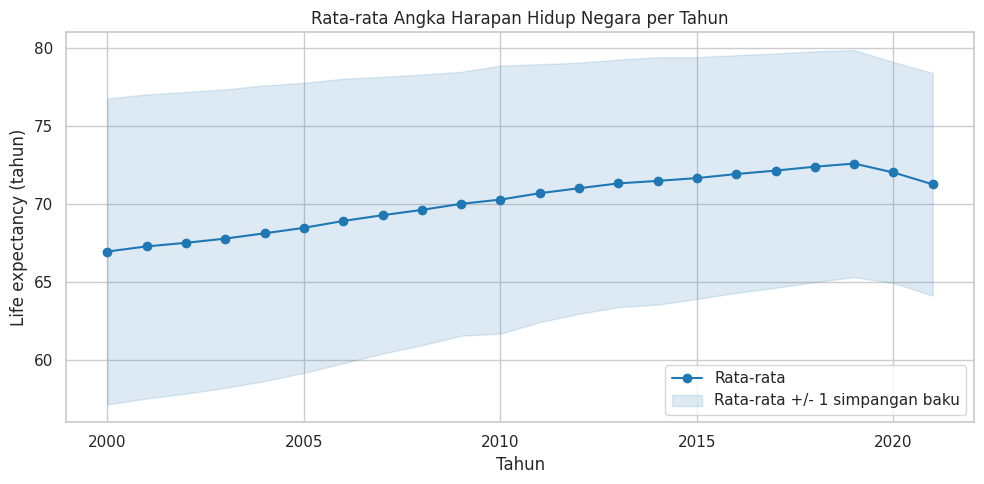

> **Insight:** Rata-rata angka harapan hidup berubah dari **66.98 tahun (2000)** menjadi **71.29 tahun (2021)**, yaitu perubahan sebesar **4.30 tahun**. Rata-rata tertinggi terjadi pada tahun 2019 (72.62) dan terendah pada tahun 2000 (66.98). Lebar pita menunjukkan variasi antar negara (simpangan baku 7.14 pada 2021).

In [ ]:
fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(yearly.index, yearly["mean"], marker="o", color="tab:blue", label="Rata-rata")
std = yearly["std"].fillna(0)
ax.fill_between(yearly.index, yearly["mean"] - std, yearly["mean"] + std, alpha=0.15, color="tab:blue", label="Rata-rata +/- 1 simpangan baku")
ax.set(title="Rata-rata Angka Harapan Hidup Negara per Tahun", xlabel="Tahun", ylabel="Life expectancy (tahun)")
ax.legend(); plt.tight_layout(); plt.show()

ins(f"Rata-rata angka harapan hidup berubah dari **{f2(m_first)} tahun ({first_year})** menjadi **{f2(m_ref)} tahun ({ref_year})**, "
    f"yaitu perubahan sebesar **{f2(m_ref - m_first)} tahun**. Rata-rata tertinggi terjadi pada tahun {int(yearly['mean'].idxmax())} ({f2(yearly['mean'].max())}) "
    f"dan terendah pada tahun {int(yearly['mean'].idxmin())} ({f2(yearly['mean'].min())}). Lebar pita menunjukkan variasi antar negara (simpangan baku {f2(yearly.loc[ref_year, 'std'])} pada {ref_year}).")

**Grafik 2: tren beberapa negara** (3 tertinggi, 3 terendah, dan Indonesia bila ada).

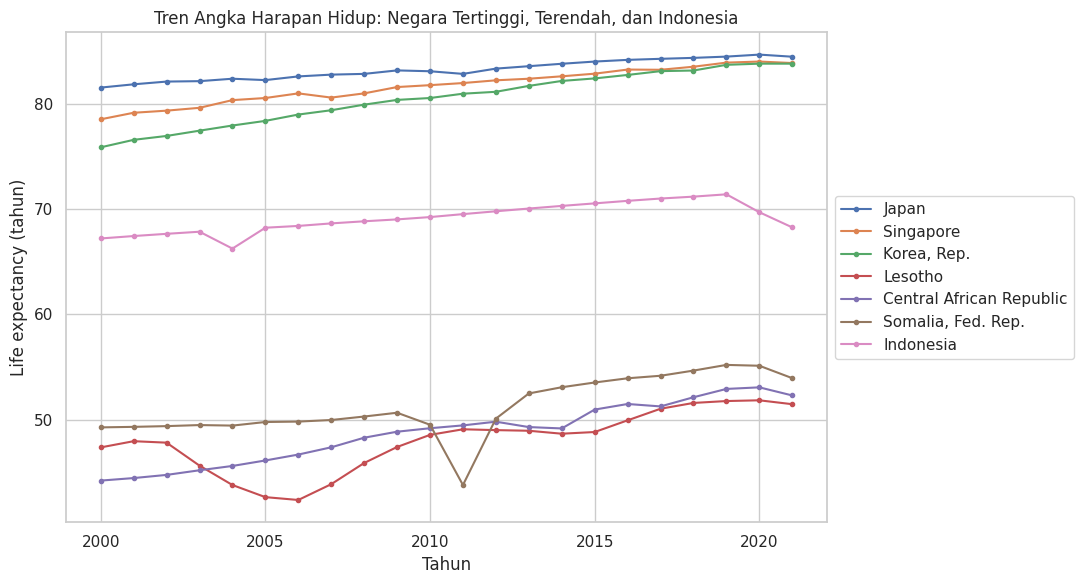

> **Insight:** Perubahan angka harapan hidup pada negara terpilih: Japan: 2.93 tahun (2000-2021); Singapore: 5.34 tahun (2000-2021); Korea, Rep.: 7.94 tahun (2000-2021); Lesotho: 4.10 tahun (2000-2021); Central African Republic: 8.08 tahun (2000-2021); Somalia, Fed. Rep.: 4.67 tahun (2000-2021); Indonesia: 1.05 tahun (2000-2021). Peningkatan terbesar di antara negara terpilih: **Central African Republic** (8.08 tahun).

In [ ]:
# Pilih negara: 3 tertinggi + 3 terendah pada tahun acuan + Indonesia (jika ada)
kode_pilih = list(d_ref.nlargest(3, TARGET)["country_code"]) + list(d_ref.nsmallest(3, TARGET)["country_code"])
kode_idn = df_final[df_final["country_name"].astype(str).str.lower().str.contains("indonesia")]["country_code"].unique()
kode_pilih += [c for c in kode_idn if c not in kode_pilih]

fig, ax = plt.subplots(figsize=(11, 6))
perubahan = []
for kode in kode_pilih:
    g = df_final[df_final.country_code == kode].sort_values("year")
    ax.plot(g["year"], g[TARGET], marker="o", markersize=3, label=g["country_name"].iloc[0])
    g = g.dropna(subset=[TARGET])
    if len(g) >= 2:
        perubahan.append((g["country_name"].iloc[0], g[TARGET].iloc[-1] - g[TARGET].iloc[0], int(g["year"].iloc[0]), int(g["year"].iloc[-1])))
ax.set(title="Tren Angka Harapan Hidup: Negara Tertinggi, Terendah, dan Indonesia", xlabel="Tahun", ylabel="Life expectancy (tahun)")
ax.legend(loc="center left", bbox_to_anchor=(1, 0.5)); plt.tight_layout(); plt.show()

if perubahan:
    terbaik = max(perubahan, key=lambda t: t[1])
    ins("Perubahan angka harapan hidup pada negara terpilih: " + "; ".join([f"{n}: {f2(v)} tahun ({a}-{b})" for n, v, a, b in perubahan]) +
        f". Peningkatan terbesar di antara negara terpilih: **{terbaik[0]}** ({f2(terbaik[1])} tahun).")

**Grafik 3: 10 negara tertinggi dan terendah** pada tahun acuan.

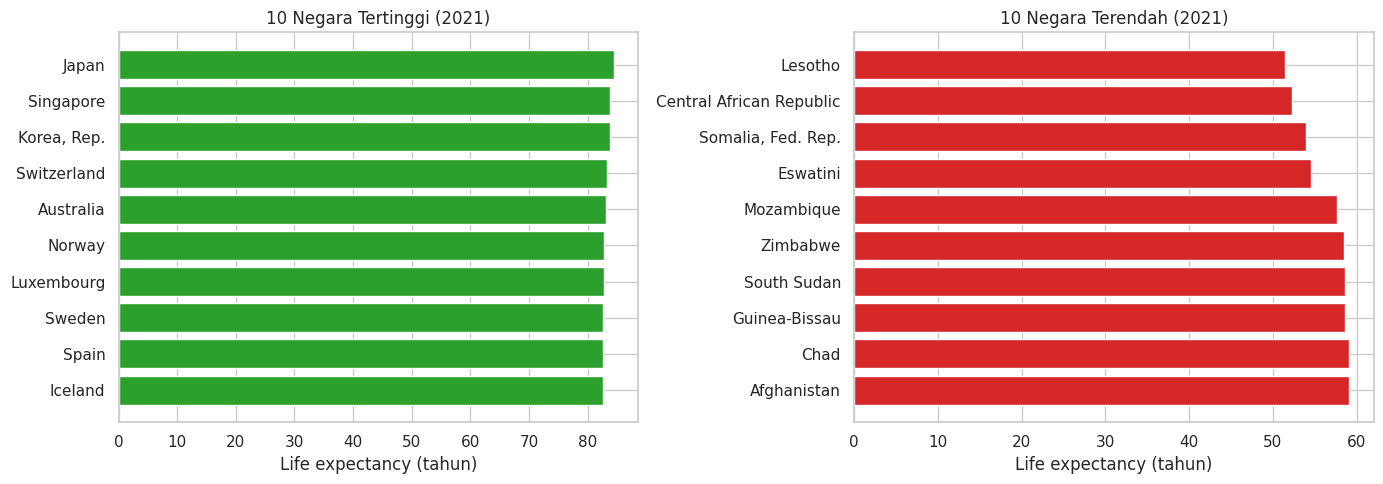

> **Insight:** Pada 2021, negara tertinggi adalah **Japan (84.46 tahun)** dan terendah **Lesotho (51.48 tahun)**, selisih **32.98 tahun**. Rata-rata 10 negara tertinggi = 83.21 tahun, 10 terendah = 56.39 tahun.

In [ ]:
top10 = d_ref.nlargest(10, TARGET).sort_values(TARGET)
bot10 = d_ref.nsmallest(10, TARGET).sort_values(TARGET, ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].barh(top10["country_name"], top10[TARGET], color="tab:green")
axes[0].set(title=f"10 Negara Tertinggi ({ref_year})", xlabel="Life expectancy (tahun)")
axes[1].barh(bot10["country_name"], bot10[TARGET], color="tab:red")
axes[1].set(title=f"10 Negara Terendah ({ref_year})", xlabel="Life expectancy (tahun)")
plt.tight_layout(); plt.show()

gap = top10[TARGET].max() - bot10[TARGET].min()
RESULTS["gap"] = gap
ins(f"Pada {ref_year}, negara tertinggi adalah **{top10.iloc[-1]['country_name']} ({f2(top10.iloc[-1][TARGET])} tahun)** dan terendah **{bot10.iloc[-1]['country_name']} ({f2(bot10.iloc[-1][TARGET])} tahun)**, "
    f"selisih **{f2(gap)} tahun**. Rata-rata 10 negara tertinggi = {f2(top10[TARGET].mean())} tahun, 10 terendah = {f2(bot10[TARGET].mean())} tahun.")

**Grafik 4: distribusi life expectancy** (keseluruhan, dan perbandingan tahun awal vs tahun akhir).

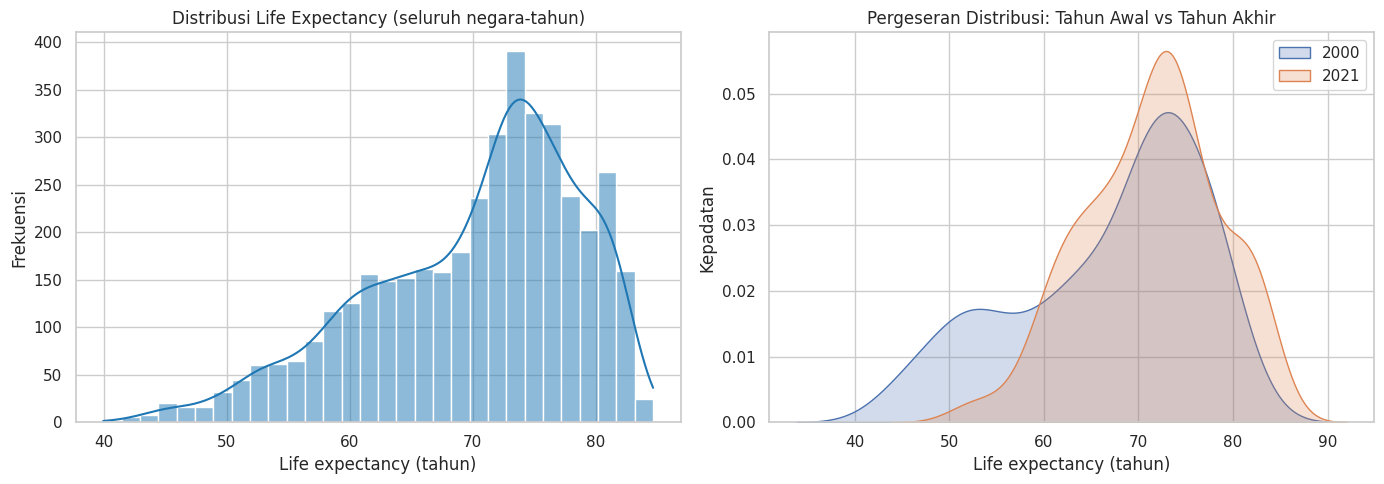

> **Insight:** Seluruh data memiliki rata-rata 70.15 tahun, median 72.29 tahun, dan skewness -0.74 (miring ke kiri: ada ekor negara berangka harapan hidup rendah). Rata-rata distribusi bergeser dari 66.98 (2000) ke 71.29 (2021).

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.histplot(df_final[TARGET].dropna(), bins=30, kde=True, ax=axes[0], color="tab:blue")
axes[0].set(title="Distribusi Life Expectancy (seluruh negara-tahun)", xlabel="Life expectancy (tahun)", ylabel="Frekuensi")
for tahun in [first_year, ref_year]:
    sns.kdeplot(df_final.loc[df_final.year == tahun, TARGET].dropna(), ax=axes[1], fill=True, label=str(tahun))
axes[1].set(title="Pergeseran Distribusi: Tahun Awal vs Tahun Akhir", xlabel="Life expectancy (tahun)", ylabel="Kepadatan")
axes[1].legend(); plt.tight_layout(); plt.show()

sk = df_final[TARGET].skew()
bentuk = "miring ke kiri: ada ekor negara berangka harapan hidup rendah" if sk < -0.2 else "miring ke kanan" if sk > 0.2 else "relatif simetris"
ins(f"Seluruh data memiliki rata-rata {f2(df_final[TARGET].mean())} tahun, median {f2(df_final[TARGET].median())} tahun, dan skewness {f2(sk)} "
    f"({bentuk}). Rata-rata distribusi bergeser dari {f2(m_first)} ({first_year}) ke {f2(m_ref)} ({ref_year}).")

**Grafik 5: perbandingan menurut region dan income group** (atas: rata-rata, bawah: sebaran/boxplot).

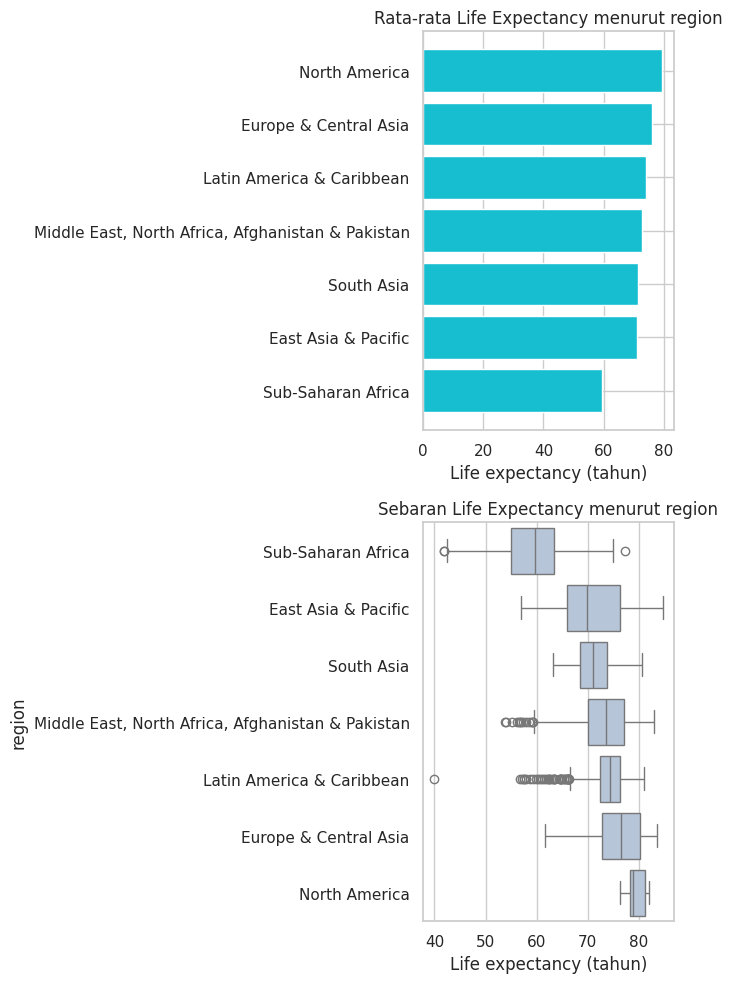

> **Insight:** menurut `region`, rata-rata tertinggi adalah **North America (79.37)** dan terendah **Sub-Saharan Africa (59.49)**, selisih 19.88 tahun. Boxplot menunjukkan seberapa lebar sebaran di dalam tiap kelompok.

In [ ]:
kelompok = [g for g, ada in [("region", has_region), ("income_group", has_income)] if ada]
if kelompok:
    fig, axes = plt.subplots(2, len(kelompok), figsize=(7 * len(kelompok), 10), squeeze=False)
    for j, g in enumerate(kelompok):
        urutan = df_final.groupby(g)[TARGET].median().sort_values().index
        rata = df_final.groupby(g)[TARGET].mean().reindex(urutan)
        axes[0, j].barh(rata.index.astype(str), rata.values, color="tab:cyan")
        axes[0, j].set(title=f"Rata-rata Life Expectancy menurut {g}", xlabel="Life expectancy (tahun)")
        sns.boxplot(data=df_final, x=TARGET, y=g, order=urutan, ax=axes[1, j], color="lightsteelblue", orient="h")
        axes[1, j].set(title=f"Sebaran Life Expectancy menurut {g}", xlabel="Life expectancy (tahun)", ylabel=g)
    plt.tight_layout(); plt.show()

    pesan = []
    for g in kelompok:
        mb = df_final.groupby(g)[TARGET].mean().sort_values()
        pesan.append(f"menurut `{g}`, rata-rata tertinggi adalah **{mb.index[-1]} ({f2(mb.iloc[-1])})** dan terendah **{mb.index[0]} ({f2(mb.iloc[0])})**, selisih {f2(mb.iloc[-1] - mb.iloc[0])} tahun")
    ins("; ".join(pesan) + ". Boxplot menunjukkan seberapa lebar sebaran di dalam tiap kelompok.")
else:
    print("Kolom region/income group tidak tersedia atau hanya satu kategori: grafik kelompok dilewati.")

## 4.2 BQ2: Adult mortality vs angka harapan hidup

Kiri: scatter plot dengan garis regresi. Kanan: titik yang sama diberi warna menurut income group.

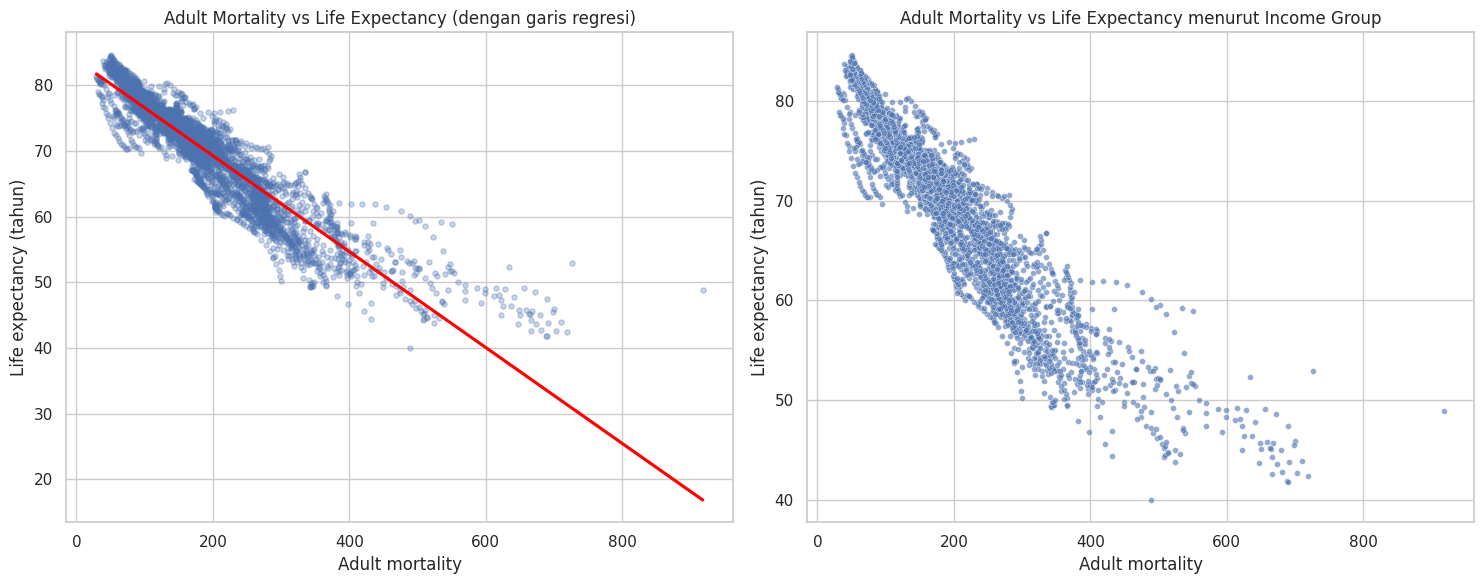

> **Insight:** Korelasi Pearson = **-0.931** (sangat kuat dan negatif) dan Spearman = -0.949 dengan n = 4063. Garis regresi menunjukkan setiap kenaikan 1 satuan adult mortality berasosiasi dengan perubahan life expectancy sebesar -0.073 tahun. Ini adalah asosiasi, bukan bukti sebab-akibat.

In [ ]:
if "adult_mortality" in FEATURES:
    d = df_final[["adult_mortality", TARGET, "income_group"]].dropna(subset=["adult_mortality", TARGET])
    fig, axes = plt.subplots(1, 2, figsize=(15, 6))
    sns.regplot(data=d, x="adult_mortality", y=TARGET, ax=axes[0], ci=None, scatter_kws={"alpha": 0.3, "s": 14}, line_kws={"color": "red"})
    axes[0].set(title="Adult Mortality vs Life Expectancy (dengan garis regresi)", xlabel="Adult mortality", ylabel="Life expectancy (tahun)")
    sns.scatterplot(data=d, x="adult_mortality", y=TARGET, hue="income_group" if has_income else None, alpha=0.6, s=18, ax=axes[1])
    if has_income:
        axes[1].legend(title="Income group", fontsize=8, loc="best")
    axes[1].set(title="Adult Mortality vs Life Expectancy menurut Income Group", xlabel="Adult mortality", ylabel="Life expectancy (tahun)")
    plt.tight_layout(); plt.show()

    kemiringan, _ = np.polyfit(d["adult_mortality"], d[TARGET], 1)
    ins(f"Korelasi Pearson = **{f2(RESULTS['r_adult'], 3)}** ({corr_desc(RESULTS['r_adult'])}) dan Spearman = {f2(RESULTS['rho_adult'], 3)} dengan n = {RESULTS['n_adult']}. "
        f"Garis regresi menunjukkan setiap kenaikan 1 satuan adult mortality berasosiasi dengan perubahan life expectancy sebesar {f2(kemiringan, 3)} tahun. "
        f"Ini adalah asosiasi, bukan bukti sebab-akibat.")
else:
    print("adult_mortality tidak tersedia.")

## 4.3 BQ3: Indikator kesehatan lain vs angka harapan hidup

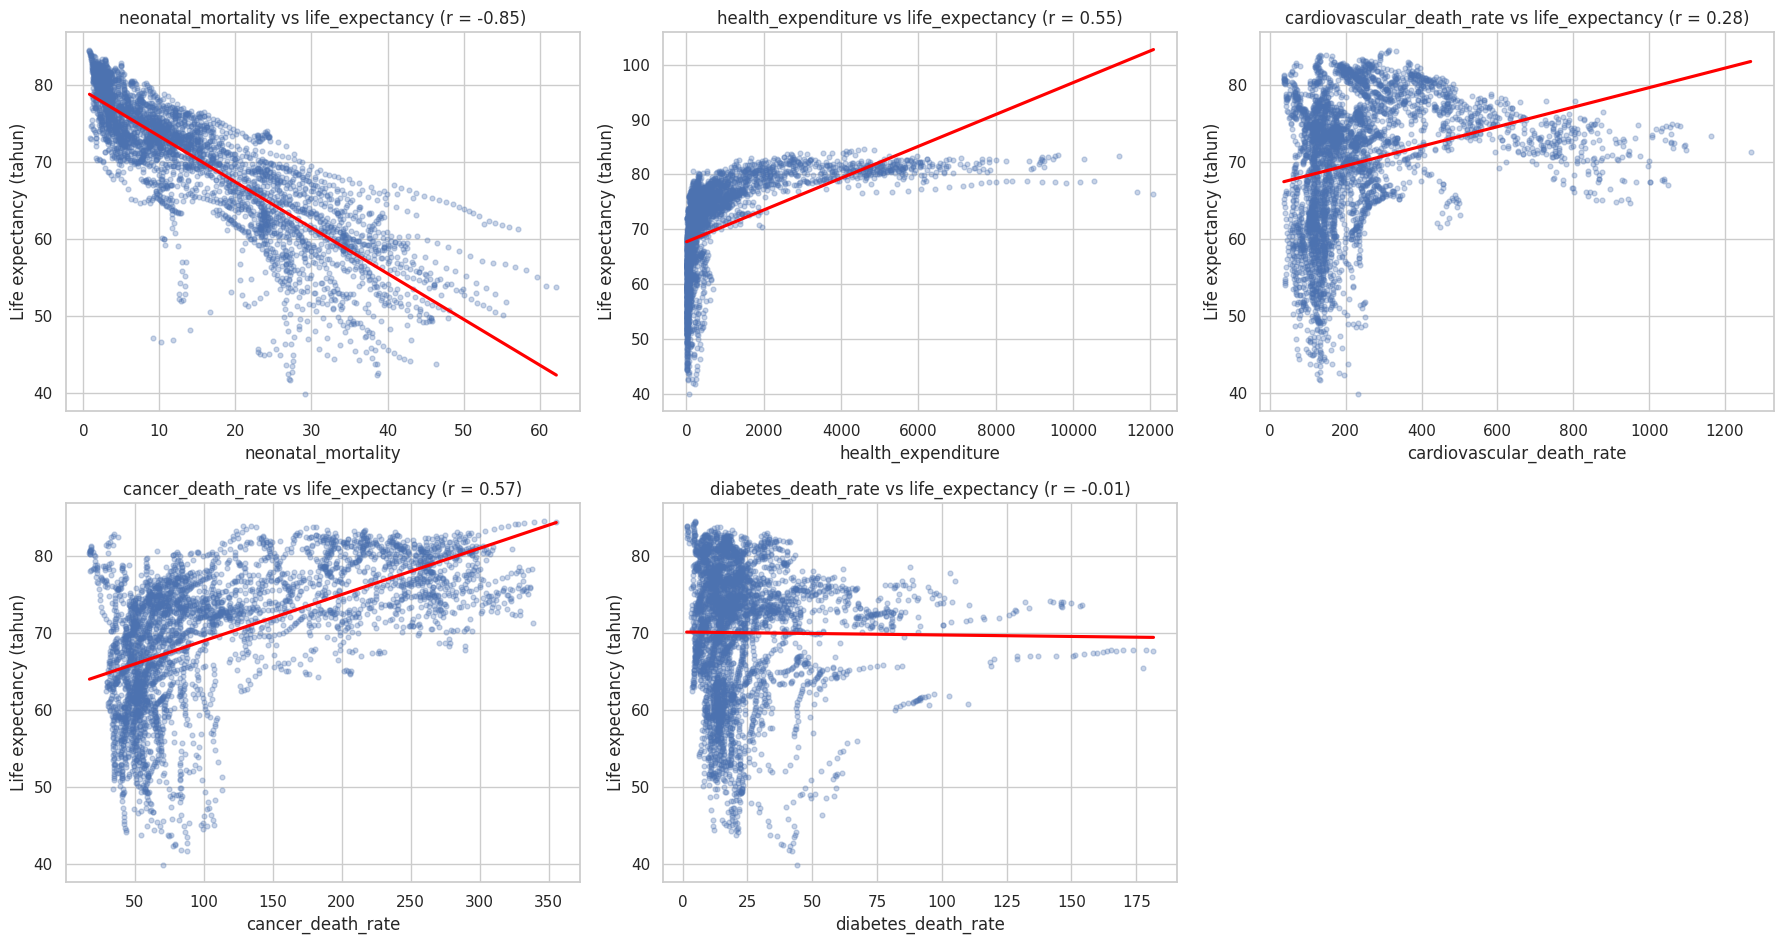

> **Insight:** Hasil korelasi Pearson terhadap life expectancy: `neonatal_mortality`: r = -0.85 (sangat kuat dan negatif); `health_expenditure`: r = 0.55 (sedang dan positif); `cardiovascular_death_rate`: r = 0.28 (lemah dan positif); `cancer_death_rate`: r = 0.57 (sedang dan positif); `diabetes_death_rate`: r = -0.01 (sangat lemah dan negatif).

In [ ]:
if OTHER_FEATURES:
    kolom = 3
    baris = int(np.ceil(len(OTHER_FEATURES) / kolom))
    fig, axes = plt.subplots(baris, kolom, figsize=(6 * kolom, 4.8 * baris), squeeze=False)
    axes = axes.flatten()
    for ax, f in zip(axes, OTHER_FEATURES):
        d = df_final[[f, TARGET]].dropna()
        if len(d) >= 3:
            sns.regplot(data=d, x=f, y=TARGET, ax=ax, ci=None, scatter_kws={"alpha": 0.3, "s": 12}, line_kws={"color": "red"})
        ax.set(title=f"{f} vs life_expectancy (r = {f2(RESULTS['corr_other'].get(f, np.nan), 2)})", xlabel=f, ylabel="Life expectancy (tahun)")
    for ax in axes[len(OTHER_FEATURES):]:
        ax.axis("off")
    plt.tight_layout(); plt.show()

    ins("Hasil korelasi Pearson terhadap life expectancy: " +
        "; ".join([f"`{f}`: r = {f2(r, 2)} ({corr_desc(r)})" for f, r in RESULTS["corr_other"].items()]) + ".")

**Ranking korelasi** semua fitur terhadap life expectancy (hijau = positif, merah = negatif).

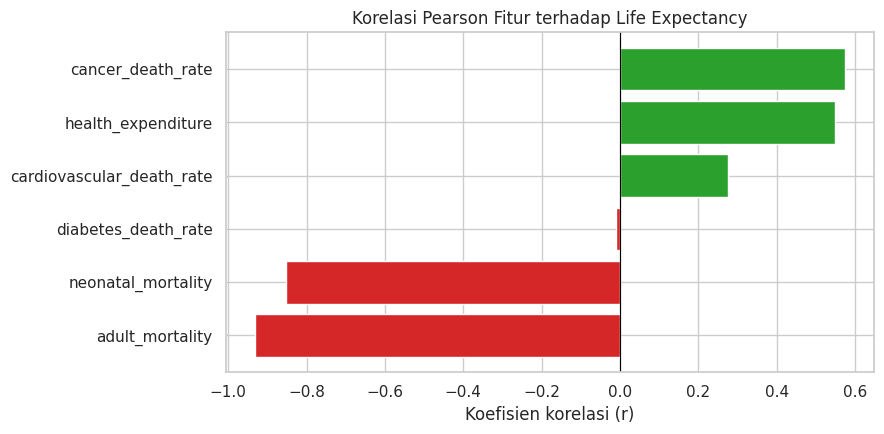

> **Insight:** Fitur dengan hubungan linear terkuat adalah **adult_mortality** (r = -0.931). Fitur bertanda negatif berasosiasi dengan life expectancy yang lebih rendah, fitur bertanda positif dengan life expectancy yang lebih tinggi.

In [ ]:
ct_all = corr_table(FEATURES).sort_values("pearson_r")
fig, ax = plt.subplots(figsize=(9, 4.5))
ax.barh(ct_all["fitur"], ct_all["pearson_r"].fillna(0), color=["tab:red" if v < 0 else "tab:green" for v in ct_all["pearson_r"].fillna(0)])
ax.axvline(0, color="black", linewidth=0.8)
ax.set(title="Korelasi Pearson Fitur terhadap Life Expectancy", xlabel="Koefisien korelasi (r)")
plt.tight_layout(); plt.show()

terkuat = ct_all.iloc[ct_all["pearson_r"].abs().fillna(0).argmax()]
RESULTS.update(strongest_corr_feature=terkuat["fitur"], strongest_corr_val=terkuat["pearson_r"])
ins(f"Fitur dengan hubungan linear terkuat adalah **{terkuat['fitur']}** (r = {f2(terkuat['pearson_r'], 3)}). "
    f"Fitur bertanda negatif berasosiasi dengan life expectancy yang lebih rendah, fitur bertanda positif dengan life expectancy yang lebih tinggi.")

**Correlation heatmap** antar semua variabel numerik.

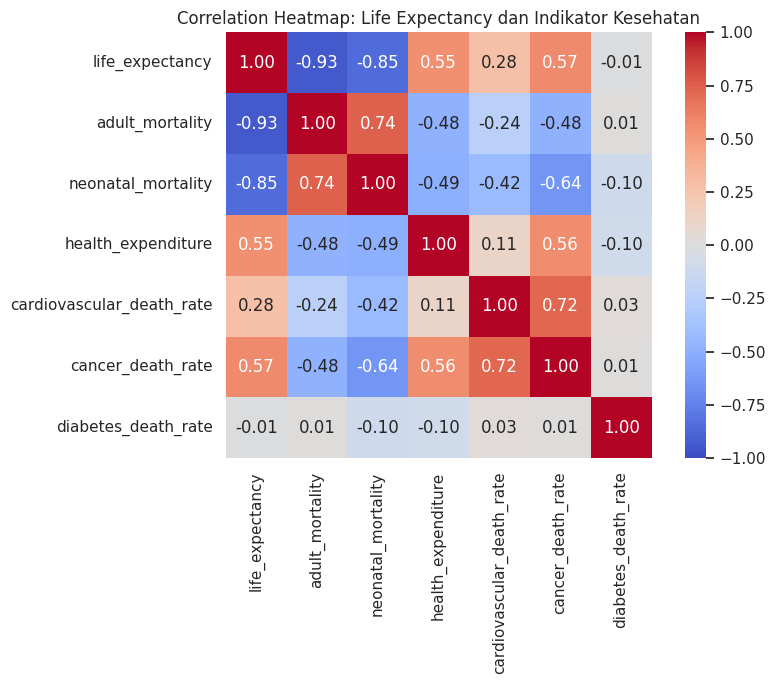

> **Insight:** Pasangan fitur dengan korelasi terkuat adalah `adult_mortality` dan `neonatal_mortality` (r = 0.74). Fitur yang saling berkorelasi tinggi bersifat redundan sehingga *feature importance* Random Forest dapat terbagi di antara keduanya.

In [ ]:
corr = df_final[[TARGET] + FEATURES].corr()
fig, ax = plt.subplots(figsize=(9, 7))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", vmin=-1, vmax=1, center=0, square=True, ax=ax)
ax.set_title("Correlation Heatmap: Life Expectancy dan Indikator Kesehatan")
plt.tight_layout(); plt.show()

# pasangan fitur (tanpa target) dengan korelasi terkuat
pasangan = corr.where(np.triu(np.ones(corr.shape), k=1).astype(bool)).stack().reset_index()
pasangan.columns = ["var1", "var2", "r"]
pasangan = pasangan[(pasangan.var1 != TARGET) & (pasangan.var2 != TARGET)]
if len(pasangan):
    hi = pasangan.iloc[pasangan["r"].abs().argmax()]
    RESULTS["max_feat_pair"] = (hi["var1"], hi["var2"], hi["r"])
    ins(f"Pasangan fitur dengan korelasi terkuat adalah `{hi['var1']}` dan `{hi['var2']}` (r = {f2(hi['r'], 2)}). "
        f"Fitur yang saling berkorelasi tinggi bersifat redundan sehingga *feature importance* Random Forest dapat terbagi di antara keduanya.")

**Pairplot** (dibatasi: target + maksimal 4 fitur, sampel maksimal 800 baris).

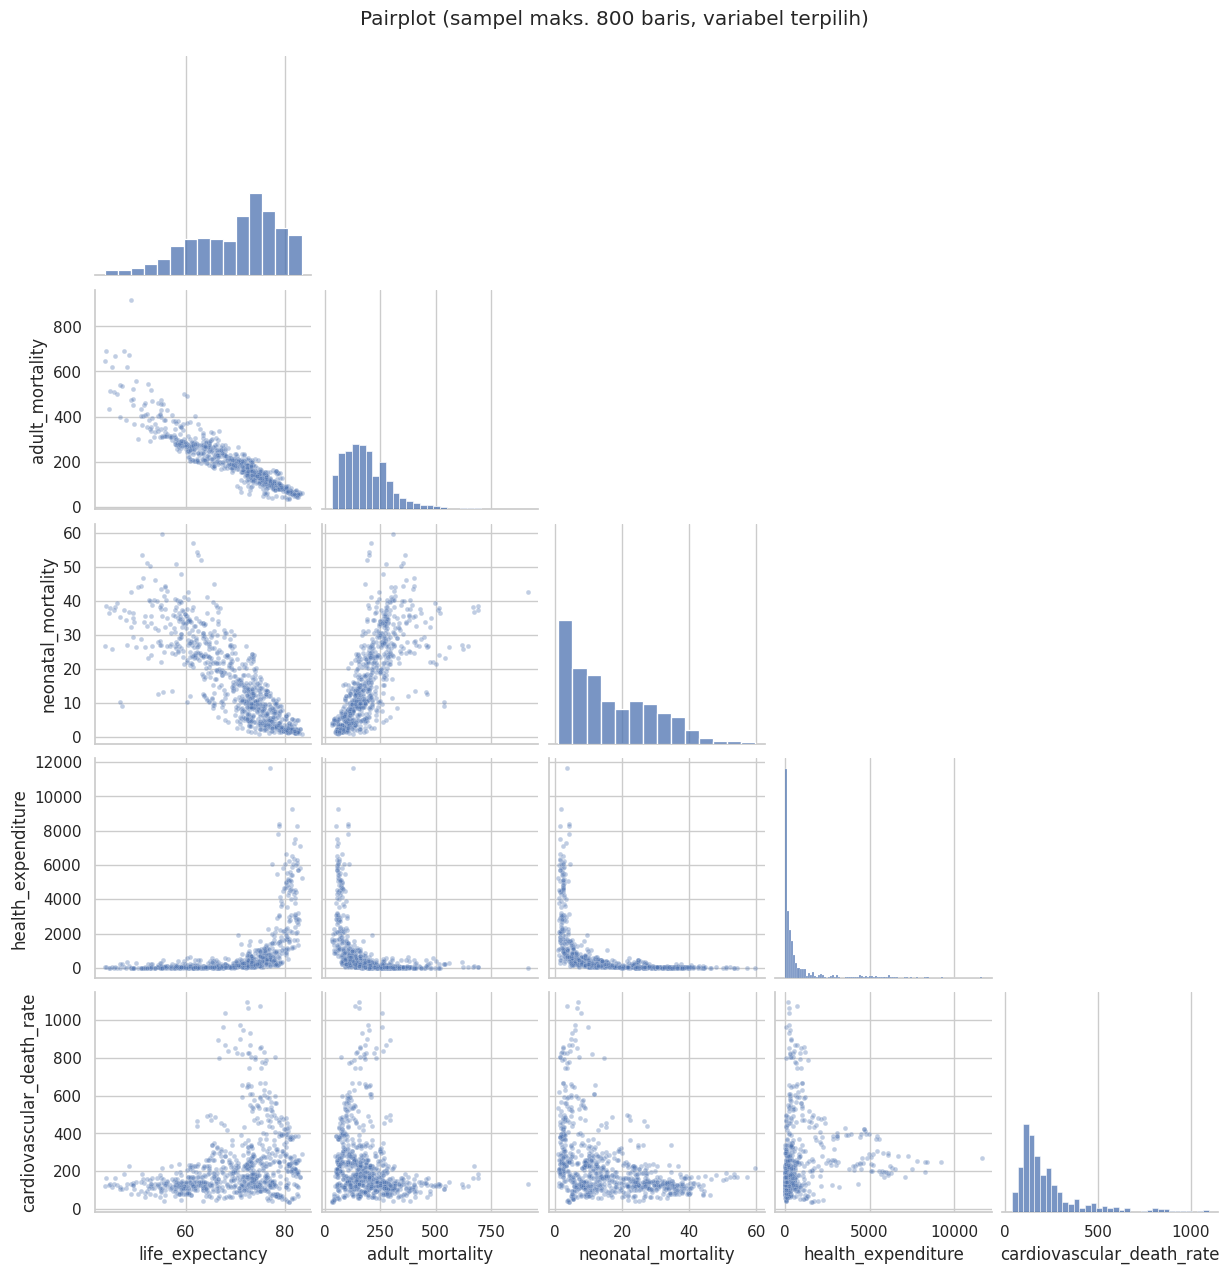

> **Insight:** Pairplot memperlihatkan bentuk hubungan antar variabel. Pola melengkung (non-linear) menandakan hubungan tidak sepenuhnya linear, sehingga model non-linear seperti Random Forest relevan.

In [ ]:
data_pp = df_final[[TARGET] + FEATURES[:4]].dropna()
if len(data_pp) > 5:
    data_pp = data_pp.sample(min(800, len(data_pp)), random_state=42)
    g = sns.pairplot(data_pp, corner=True, diag_kind="hist", plot_kws={"alpha": 0.35, "s": 12})
    g.fig.suptitle("Pairplot (sampel maks. 800 baris, variabel terpilih)", y=1.02)
    plt.show()
    ins("Pairplot memperlihatkan bentuk hubungan antar variabel. Pola melengkung (non-linear) menandakan hubungan tidak sepenuhnya linear, sehingga model non-linear seperti Random Forest relevan.")
else:
    print("Data lengkap terlalu sedikit untuk pairplot.")

# 5. Analisis Lanjutan

Analisis tambahan: (a) perbandingan korelasi Pearson dan Spearman, (b) korelasi per income group, (c) tren per kelompok negara.

> **Penting:** korelasi **tidak otomatis berarti sebab-akibat**. Hubungan yang tampak dapat dipengaruhi faktor lain (misalnya tingkat pendapatan negara) yang tidak ada di data.

**(a) Pearson vs Spearman.** Pearson mengukur hubungan garis lurus, Spearman mengukur hubungan searah (monoton).

,n,pearson_r,pearson_p,spearman_rho,spearman_p
fitur,,,,,
adult_mortality,4063,-0.9308,0.0000,-0.9493,0.0000
neonatal_mortality,4048,-0.8534,0.0000,-0.8828,0.0000
health_expenditure,3948,0.5486,0.0000,0.8486,0.0000
cardiovascular_death_rate,4026,0.2755,0.0000,0.3771,0.0000
cancer_death_rate,4026,0.5733,0.0000,0.6249,0.0000
diabetes_death_rate,4026,-0.0094,0.5527,-0.0269,0.0876


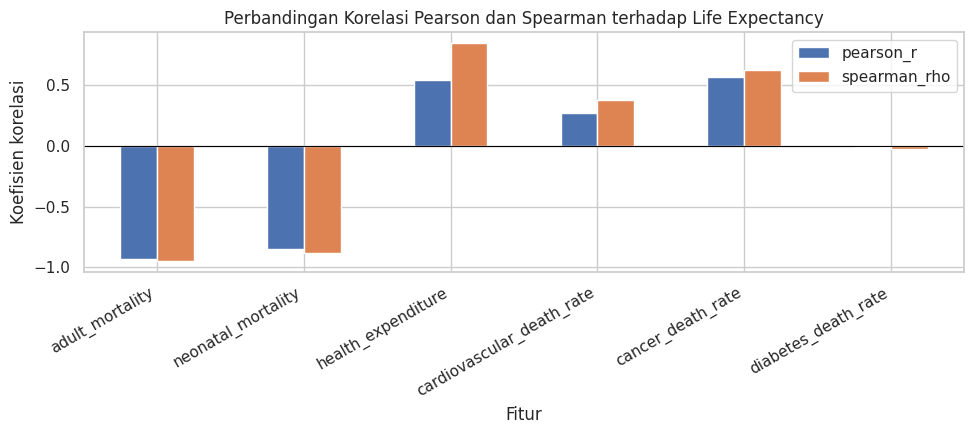

> **Insight:** Selisih terbesar antara |Spearman| dan |Pearson| ada pada `health_expenditure` (0.300). Jika Spearman lebih besar, hubungannya cenderung monoton tetapi tidak linear.

In [ ]:
ct = corr_table(FEATURES).set_index("fitur")
display(ct.round(4))

fig, ax = plt.subplots(figsize=(10, 4.5))
ct[["pearson_r", "spearman_rho"]].plot(kind="bar", ax=ax)
ax.axhline(0, color="black", linewidth=0.8)
ax.set(title="Perbandingan Korelasi Pearson dan Spearman terhadap Life Expectancy", ylabel="Koefisien korelasi", xlabel="Fitur")
plt.xticks(rotation=30, ha="right"); plt.tight_layout(); plt.show()

selisih = (ct["spearman_rho"].abs() - ct["pearson_r"].abs()).dropna()
if len(selisih):
    ins(f"Selisih terbesar antara |Spearman| dan |Pearson| ada pada `{selisih.abs().idxmax()}` ({f2(selisih.loc[selisih.abs().idxmax()], 3)}). "
        f"Jika Spearman lebih besar, hubungannya cenderung monoton tetapi tidak linear.")

**(b) Korelasi per income group.** Apakah kekuatan hubungan berbeda di tiap kelompok pendapatan?

In [ ]:
if has_income:
    korelasi_grup = {}
    for grup, d_grup in df_final.groupby("income_group"):
        korelasi_grup[grup] = {}
        for f in FEATURES:
            d = d_grup[[f, TARGET]].dropna()
            korelasi_grup[grup][f] = d[f].corr(d[TARGET]) if (len(d) >= 10 and d[f].nunique() > 1) else np.nan
    cg = pd.DataFrame(korelasi_grup)
    if cg.notna().any().any():
        fig, ax = plt.subplots(figsize=(9, 5))
        sns.heatmap(cg, annot=True, fmt=".2f", cmap="coolwarm", vmin=-1, vmax=1, center=0, ax=ax)
        ax.set(title="Korelasi Fitur terhadap Life Expectancy per Income Group", xlabel="Income group", ylabel="Fitur")
        plt.tight_layout(); plt.show()
        rata_abs = cg.abs().mean(axis=1).dropna()
        ins(f"Di dalam kelompok pendapatan, kekuatan hubungan bisa berbeda dari korelasi keseluruhan. Rata-rata |r| tertinggi lintas kelompok ada pada `{rata_abs.idxmax()}` ({f2(rata_abs.max(), 2)}). "
            f"Sel kosong berarti data kelompok tersebut kurang dari 10 observasi.")
else:
    print("Income group tidak tersedia: analisis per income group dilewati.")

Income group tidak tersedia: analisis per income group dilewati.


**(c) Tren per income group dan per region.**

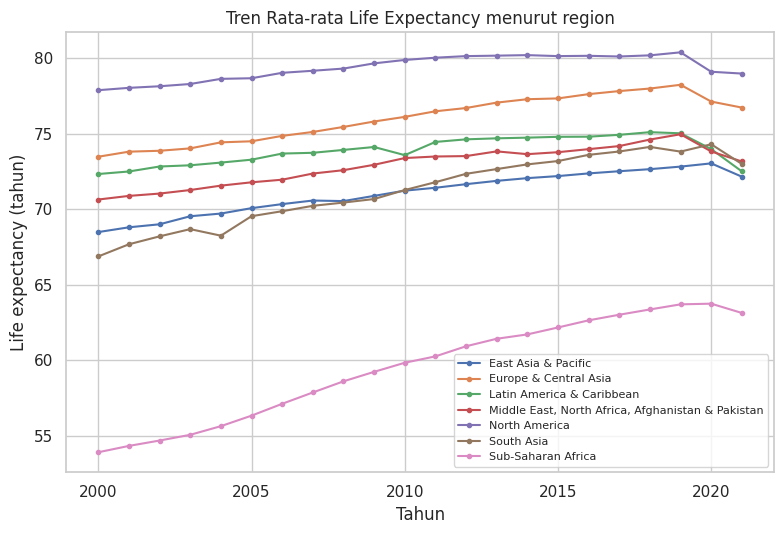

> **Insight:** menurut `region`, peningkatan 2000-2021 terbesar pada **Sub-Saharan Africa (+9.22 tahun)** dan terkecil pada **Latin America & Caribbean (0.17 tahun)**.

In [ ]:
panel = [g for g, ada in [("income_group", has_income), ("region", has_region)] if ada]
if panel:
    fig, axes = plt.subplots(1, len(panel), figsize=(8 * len(panel), 5.5), squeeze=False)
    for ax, g in zip(axes[0], panel):
        tren = df_final.groupby(["year", g])[TARGET].mean().reset_index()
        for nama, d in tren.groupby(g):
            ax.plot(d["year"], d[TARGET], marker="o", markersize=3, label=str(nama))
        ax.set(title=f"Tren Rata-rata Life Expectancy menurut {g}", xlabel="Tahun", ylabel="Life expectancy (tahun)")
        ax.legend(fontsize=8, loc="best")
    plt.tight_layout(); plt.show()

    pesan = []
    for g in panel:
        awal = df_final[df_final.year == first_year].groupby(g)[TARGET].mean()
        akhir = df_final[df_final.year == ref_year].groupby(g)[TARGET].mean()
        delta = (akhir - awal).dropna().sort_values()
        if len(delta):
            pesan.append(f"menurut `{g}`, peningkatan {first_year}-{ref_year} terbesar pada **{delta.index[-1]} (+{f2(delta.iloc[-1])} tahun)** dan terkecil pada **{delta.index[0]} ({f2(delta.iloc[0])} tahun)**")
    if pesan:
        ins("; ".join(pesan) + ".")
else:
    print("Region/income group tidak tersedia: tren kelompok dilewati.")

# 6. Model Machine Learning: Random Forest Regressor

## 6.1 Persiapan Data ML (Feature Selection)

* **Target (y):** `life_expectancy`
* **Fitur (X):** indikator yang benar-benar ada di `df_final` (adult mortality, neonatal mortality, health expenditure, cardiovascular/cancer/diabetes death rate).
* **Tidak dipakai sebagai fitur:** `life_expectancy` (target, mencegah leakage), `country_code` dan `country_name` (identitas), `region` dan `income_group` (hanya untuk EDA), serta `year` (agar model tidak sekadar mengikuti tren waktu).

In [ ]:
# Pengaman: pastikan tidak ada kolom terlarang di fitur (mencegah data leakage)
assert TARGET not in FEATURES, "Target tidak boleh menjadi fitur"
for terlarang in ["country_code", "country_name", "region", "income_group", "year"]:
    assert terlarang not in FEATURES, f"{terlarang} tidak boleh menjadi fitur"
if len(FEATURES) == 0:
    raise ValueError("Tidak ada fitur terdeteksi. Periksa hasil deteksi kolom di 2.5.")

df_ml = df_final.dropna(subset=[TARGET]).reset_index(drop=True)
print("Fitur :", FEATURES)
print("Target:", TARGET)
print("Jumlah baris ML:", len(df_ml))

Fitur : ['adult_mortality', 'neonatal_mortality', 'health_expenditure', 'cardiovascular_death_rate', 'cancer_death_rate', 'diabetes_death_rate']
Target: life_expectancy
Jumlah baris ML: 4070


## 6.2 Temporal Train-Test Split

Data tahunan dibagi **berdasarkan waktu**: data latih = tahun <= 2019, data uji = tahun 2020-2021. Kode memeriksa dulu tahun yang tersedia. Jika tidak sesuai, muncul pesan dan dipakai pembagian temporal yang paling cocok dengan data.

In [ ]:
tahun_ada = sorted(df_ml["year"].unique().tolist())
print("Tahun tersedia:", tahun_ada)

if any(y <= 2019 for y in tahun_ada) and any(y >= 2020 for y in tahun_ada):
    # kasus normal: latih <= 2019, uji >= 2020
    train_idx = df_ml.index[df_ml["year"] <= 2019]
    test_idx  = df_ml.index[df_ml["year"] >= 2020]
    print("Temporal sesuai rencana: train <= 2019, test >= 2020")
elif len(tahun_ada) >= 2:
    # tahun 2020-2021 tidak ada: pakai ~20% tahun terakhir sebagai data uji
    n_uji = max(1, int(round(0.2 * len(tahun_ada))))
    tahun_uji = tahun_ada[-n_uji:]
    train_idx = df_ml.index[~df_ml["year"].isin(tahun_uji)]
    test_idx  = df_ml.index[df_ml["year"].isin(tahun_uji)]
    print(f"PESAN: tahun 2020-2021 tidak tersedia -> memakai tahun terakhir {tahun_uji} sebagai data uji (temporal)")
else:
    # hanya 1 tahun: pisahkan per negara
    pos_tr, pos_te = next(GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=42).split(df_ml, groups=df_ml["country_code"]))
    train_idx, test_idx = df_ml.index[pos_tr], df_ml.index[pos_te]
    print("PESAN: data hanya satu tahun -> split temporal tidak mungkin; dipakai split per negara")

assert len(train_idx) > 0 and len(test_idx) > 0, "Data latih/uji kosong"
print(f"Train: {len(train_idx)} baris, tahun {df_ml.loc[train_idx, 'year'].min()}-{df_ml.loc[train_idx, 'year'].max()}")
print(f"Test : {len(test_idx)} baris, tahun {df_ml.loc[test_idx, 'year'].min()}-{df_ml.loc[test_idx, 'year'].max()}")
if len(test_idx) < 5 or len(train_idx) < 10:
    print("PERINGATAN: data latih/uji sangat sedikit, hasil evaluasi kurang stabil.")

X_train_raw, y_train = df_ml.loc[train_idx, FEATURES], df_ml.loc[train_idx, TARGET]
X_test_raw,  y_test  = df_ml.loc[test_idx, FEATURES],  df_ml.loc[test_idx, TARGET]

Tahun tersedia: [2000, 2001, 2002, 2003, 2004, 2005, 2006, 2007, 2008, 2009, 2010, 2011, 2012, 2013, 2014, 2015, 2016, 2017, 2018, 2019, 2020, 2021]
Temporal sesuai rencana: train <= 2019, test >= 2020
Train: 3700 baris, tahun 2000-2019
Test : 370 baris, tahun 2020-2021


## 6.3 Missing Value untuk ML

Metode: **imputasi median**. Median dihitung **hanya dari data latih**, lalu dipakai juga untuk data uji, sehingga tidak ada data leakage. Baris tidak dihapus. Fitur yang kosong seluruhnya di data latih (jika ada) dikeluarkan.

In [ ]:
print("Missing pada y (train / test):", int(y_train.isna().sum()), "/", int(y_test.isna().sum()))
print("Missing pada X_train:"); display(X_train_raw.isna().sum().to_frame("missing").T)
print("Missing pada X_test:");  display(X_test_raw.isna().sum().to_frame("missing").T)

# fitur yang kosong total di data latih tidak bisa diimputasi -> dikeluarkan
kosong = [c for c in FEATURES if X_train_raw[c].isna().all()]
if kosong:
    print("PERINGATAN: fitur kosong seluruhnya pada data latih, dikeluarkan:", kosong)
FEATURES_ML = [c for c in FEATURES if c not in kosong]
if not FEATURES_ML:
    raise ValueError("Semua fitur kosong pada data latih.")

imputer = SimpleImputer(strategy="median")
X_train = pd.DataFrame(imputer.fit_transform(X_train_raw[FEATURES_ML]), columns=FEATURES_ML, index=X_train_raw.index)  # fit hanya di train
X_test  = pd.DataFrame(imputer.transform(X_test_raw[FEATURES_ML]),      columns=FEATURES_ML, index=X_test_raw.index)
print("Median dari data latih yang dipakai:"); display(pd.Series(imputer.statistics_, index=FEATURES_ML).round(3).to_frame("median").T)
print("Sisa missing setelah imputasi -> train:", int(X_train.isna().sum().sum()), "| test:", int(X_test.isna().sum().sum()))

Missing pada y (train / test): 0 / 0
Missing pada X_train:


,adult_mortality,neonatal_mortality,health_expenditure,cardiovascular_death_rate,cancer_death_rate,diabetes_death_rate
missing,1,20,117,40,40,40


Missing pada X_test:


,adult_mortality,neonatal_mortality,health_expenditure,cardiovascular_death_rate,cancer_death_rate,diabetes_death_rate
missing,6,2,5,4,4,4


Median dari data latih yang dipakai:


,adult_mortality,neonatal_mortality,health_expenditure,cardiovascular_death_rate,cancer_death_rate,diabetes_death_rate
median,167.28,11.95,218.82,174.29,79.73,17.02


Sisa missing setelah imputasi -> train: 0 | test: 0


## 6.4 Training Random Forest

In [ ]:
model = RandomForestRegressor(
    n_estimators=100,
    random_state=42
)
model.fit(X_train, y_train)
print("Model selesai dilatih dengan", X_train.shape[0], "baris dan", X_train.shape[1], "fitur.")

Model selesai dilatih dengan 3700 baris dan 6 fitur.


## 6.5 Prediction

In [ ]:
y_pred = model.predict(X_test)
y_pred_train = model.predict(X_train)

# Tabel hasil prediksi: nilai aktual, prediksi, dan error
df_pred = df_ml.loc[test_idx, ["country_code", "country_name", "year"]].copy()
df_pred["actual_life_expectancy"] = y_test.values
df_pred["predicted_life_expectancy"] = y_pred
df_pred["error"] = df_pred["predicted_life_expectancy"] - df_pred["actual_life_expectancy"]
df_pred["abs_error"] = df_pred["error"].abs()
df_pred = df_pred.reset_index(drop=True)
display(df_pred.head(10))
print("Ukuran df_pred:", df_pred.shape)

,country_code,country_name,year,actual_life_expectancy,predicted_life_expectancy,error,abs_error
0,AFG,Afghanistan,2020,60.49,59.9468,-0.5432,0.5432
1,AFG,Afghanistan,2021,59.13,58.7023,-0.4277,0.4277
2,AGO,Angola,2020,62.65,65.8835,3.2335,3.2335
3,AGO,Angola,2021,62.13,65.2334,3.1034,3.1034
4,ALB,Albania,2020,76.53,76.9535,0.4235,0.4235
5,ALB,Albania,2021,76.39,76.3770,-0.0130,0.0130
6,ARE,United Arab Emirates,2020,80.13,79.9866,-0.1434,0.1434
7,ARE,United Arab Emirates,2021,78.31,78.9390,0.6290,0.6290
8,ARG,Argentina,2020,76.23,76.3779,0.1479,0.1479
9,ARG,Argentina,2021,74.57,74.1539,-0.4161,0.4161


Ukuran df_pred: (370, 7)


## 6.6 Model Evaluation

| Metrik | Arti sederhana |
|---|---|
| **MAE** (Mean Absolute Error) | Rata-rata selisih mutlak prediksi dan nilai asli, dalam **tahun**. Makin kecil makin baik. |
| **RMSE** (Root Mean Squared Error) | Seperti MAE tetapi lebih menghukum kesalahan besar; satuan **tahun**. Makin kecil makin baik. |
| **R²** | Proporsi variasi life expectancy yang dijelaskan model. 1 = sempurna, 0 = sama dengan menebak rata-rata, negatif = lebih buruk dari rata-rata. |

In [ ]:
def hitung_metrik(y_asli, y_hat):
    mae = mean_absolute_error(y_asli, y_hat)
    rmse = float(np.sqrt(mean_squared_error(y_asli, y_hat)))
    r2 = r2_score(y_asli, y_hat) if len(y_asli) >= 2 else np.nan
    return mae, rmse, r2

mae_te, rmse_te, r2_te = hitung_metrik(y_test, y_pred)
mae_tr, rmse_tr, r2_tr = hitung_metrik(y_train, y_pred_train)

df_metrics = pd.DataFrame({"Data": ["Train", "Test"],
                           "MAE (tahun)": [mae_tr, mae_te],
                           "RMSE (tahun)": [rmse_tr, rmse_te],
                           "R2": [r2_tr, r2_te]}).round(4)
display(df_metrics)
RESULTS.update(mae=mae_te, rmse=rmse_te, r2=r2_te, mae_tr=mae_tr, r2_tr=r2_tr, n_test=len(y_test), n_train=len(y_train))

overfit = (not np.isnan(r2_te)) and (r2_tr - r2_te > 0.1)
ins(f"Pada data uji ({len(y_test)} baris), rata-rata kesalahan prediksi (MAE) = **{f2(mae_te)} tahun**, RMSE = **{f2(rmse_te)} tahun**, R² = **{f2(r2_te, 3)}**. "
    f"Pada data latih R² = {f2(r2_tr, 3)}. "
    + ("Selisih besar antara R² latih dan uji menandakan model cenderung overfitting." if overfit else "Selisih R² latih dan uji relatif kecil, sehingga tidak terlihat overfitting yang berat."))

,Data,MAE (tahun),RMSE (tahun),R2
0,Train,0.1967,0.3251,0.9986
1,Test,1.1087,1.5728,0.9509


> **Insight:** Pada data uji (370 baris), rata-rata kesalahan prediksi (MAE) = **1.11 tahun**, RMSE = **1.57 tahun**, R² = **0.951**. Pada data latih R² = 0.999. Selisih R² latih dan uji relatif kecil, sehingga tidak terlihat overfitting yang berat.

## 6.7 Visualisasi Hasil Model

**Grafik 1 dan 2: Actual vs Predicted.** Titik dekat garis merah (y = x) berarti prediksi mendekati nilai sebenarnya. Kiri: semua data uji. Kanan: dipisah menurut tahun.

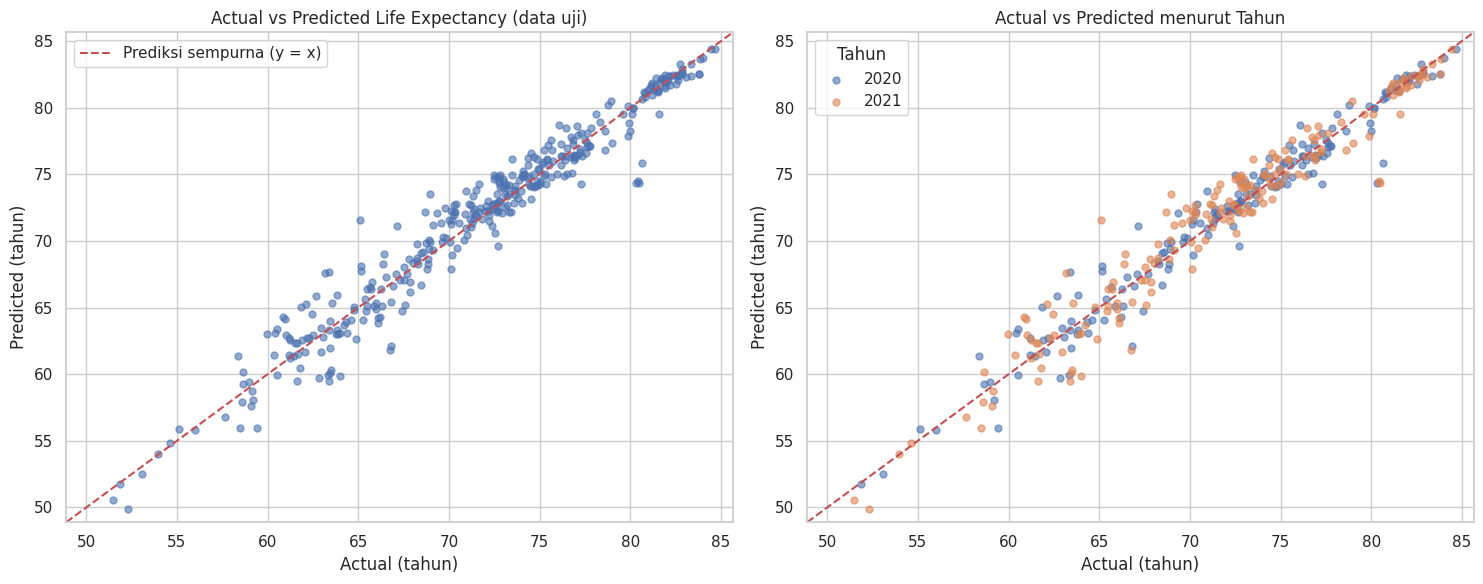

> **Insight:** Titik yang berada dekat garis merah berarti prediksi mendekati nilai sebenarnya. Pada data uji, korelasi antara aktual dan prediksi = 0.976, dengan MAE 1.11 tahun.

In [ ]:
batas_bawah = min(df_pred["actual_life_expectancy"].min(), df_pred["predicted_life_expectancy"].min()) - 1
batas_atas  = max(df_pred["actual_life_expectancy"].max(), df_pred["predicted_life_expectancy"].max()) + 1

fig, axes = plt.subplots(1, 2, figsize=(15, 6))
axes[0].scatter(df_pred["actual_life_expectancy"], df_pred["predicted_life_expectancy"], alpha=0.6, s=25)
axes[0].plot([batas_bawah, batas_atas], [batas_bawah, batas_atas], "r--", label="Prediksi sempurna (y = x)")
axes[0].set(title="Actual vs Predicted Life Expectancy (data uji)", xlabel="Actual (tahun)", ylabel="Predicted (tahun)",
            xlim=(batas_bawah, batas_atas), ylim=(batas_bawah, batas_atas))
axes[0].legend()

for tahun, g in df_pred.groupby("year"):
    axes[1].scatter(g["actual_life_expectancy"], g["predicted_life_expectancy"], alpha=0.6, s=25, label=str(int(tahun)))
axes[1].plot([batas_bawah, batas_atas], [batas_bawah, batas_atas], "r--")
axes[1].set(title="Actual vs Predicted menurut Tahun", xlabel="Actual (tahun)", ylabel="Predicted (tahun)",
            xlim=(batas_bawah, batas_atas), ylim=(batas_bawah, batas_atas))
axes[1].legend(title="Tahun")
plt.tight_layout(); plt.show()

korelasi_pred = np.corrcoef(df_pred["actual_life_expectancy"], df_pred["predicted_life_expectancy"])[0, 1] if len(df_pred) > 1 else np.nan
ins(f"Titik yang berada dekat garis merah berarti prediksi mendekati nilai sebenarnya. Pada data uji, korelasi antara aktual dan prediksi = {f2(korelasi_pred, 3)}, "
    f"dengan MAE {f2(mae_te)} tahun.")

**Grafik 3: rata-rata Actual vs Predicted per tahun uji.**

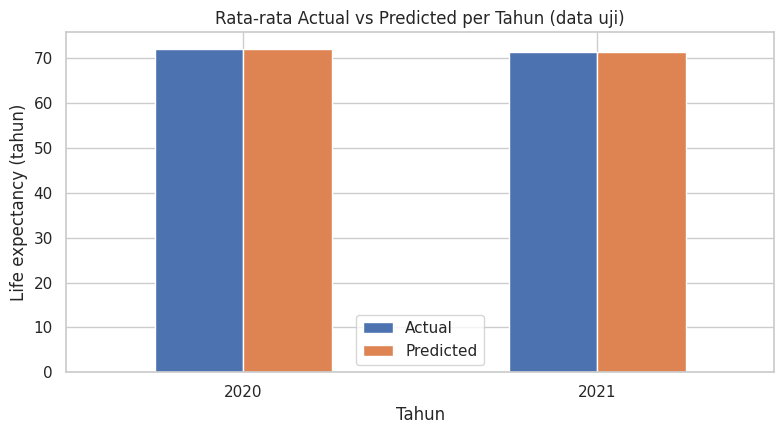

> **Insight:** Rata-rata per tahun uji: 2020: aktual 72.05 vs prediksi 72.15; 2021: aktual 71.29 vs prediksi 71.46.

In [ ]:
per_tahun = df_pred.groupby("year")[["actual_life_expectancy", "predicted_life_expectancy"]].mean()
fig, ax = plt.subplots(figsize=(8, 4.5))
per_tahun.plot(kind="bar", ax=ax)
ax.set(title="Rata-rata Actual vs Predicted per Tahun (data uji)", xlabel="Tahun", ylabel="Life expectancy (tahun)")
ax.legend(["Actual", "Predicted"]); plt.xticks(rotation=0); plt.tight_layout(); plt.show()

ins("Rata-rata per tahun uji: " + "; ".join([f"{int(t)}: aktual {f2(r.iloc[0])} vs prediksi {f2(r.iloc[1])}" for t, r in per_tahun.iterrows()]) + ".")

**Grafik 4: distribusi error** (kiri) dan error terhadap nilai prediksi (kanan).

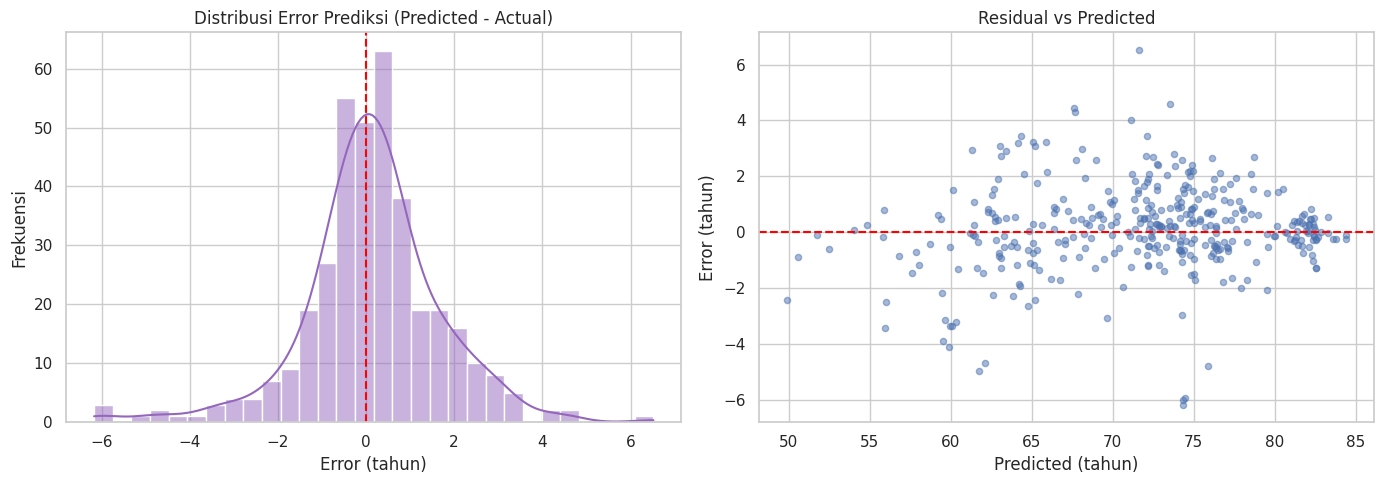

> **Insight:** Rata-rata error (bias) = 0.14 tahun (model cenderung menaksir terlalu tinggi). Error terbesar (mutlak) = 6.52 tahun; 90% prediksi memiliki selisih <= 2.59 tahun.

10 prediksi dengan error terbesar:


,country_code,country_name,year,actual_life_expectancy,predicted_life_expectancy,error,abs_error
117,GAB,Gabon,2021,65.09,71.61,6.52,6.52
87,DEU,Germany,2021,80.49,74.32,-6.17,6.17
310,SVN,Slovenia,2020,80.34,74.35,-5.99,5.99
311,SVN,Slovenia,2021,80.41,74.47,-5.94,5.94
173,KEN,Kenya,2021,66.76,61.78,-4.98,4.98
194,LKA,Sri Lanka,2020,80.66,75.87,-4.79,4.79
172,KEN,Kenya,2020,66.79,62.11,-4.68,4.68
141,HND,Honduras,2021,68.96,73.55,4.59,4.59
71,COG,"Congo, Rep.",2021,63.17,67.60,4.43,4.43
70,COG,"Congo, Rep.",2020,63.36,67.66,4.30,4.30


In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.histplot(df_pred["error"], bins=30, kde=True, ax=axes[0], color="tab:purple")
axes[0].axvline(0, color="red", linestyle="--")
axes[0].set(title="Distribusi Error Prediksi (Predicted - Actual)", xlabel="Error (tahun)", ylabel="Frekuensi")
axes[1].scatter(df_pred["predicted_life_expectancy"], df_pred["error"], alpha=0.5, s=20)
axes[1].axhline(0, color="red", linestyle="--")
axes[1].set(title="Residual vs Predicted", xlabel="Predicted (tahun)", ylabel="Error (tahun)")
plt.tight_layout(); plt.show()

bias = df_pred["error"].mean()
arah = "model cenderung menaksir terlalu tinggi" if bias > 0.1 else "model cenderung menaksir terlalu rendah" if bias < -0.1 else "hampir tanpa bias sistematis"
ins(f"Rata-rata error (bias) = {f2(bias)} tahun ({arah}). "
    f"Error terbesar (mutlak) = {f2(df_pred['abs_error'].max())} tahun; 90% prediksi memiliki selisih <= {f2(df_pred['abs_error'].quantile(0.9))} tahun.")
print("10 prediksi dengan error terbesar:")
display(df_pred.sort_values("abs_error", ascending=False).head(10).round(2))

**Grafik 5: feature importance** (urut dari yang paling penting).

,feature,importance
0,adult_mortality,0.8912
1,neonatal_mortality,0.0416
2,health_expenditure,0.0338
3,cardiovascular_death_rate,0.0125
4,diabetes_death_rate,0.0105
5,cancer_death_rate,0.0105


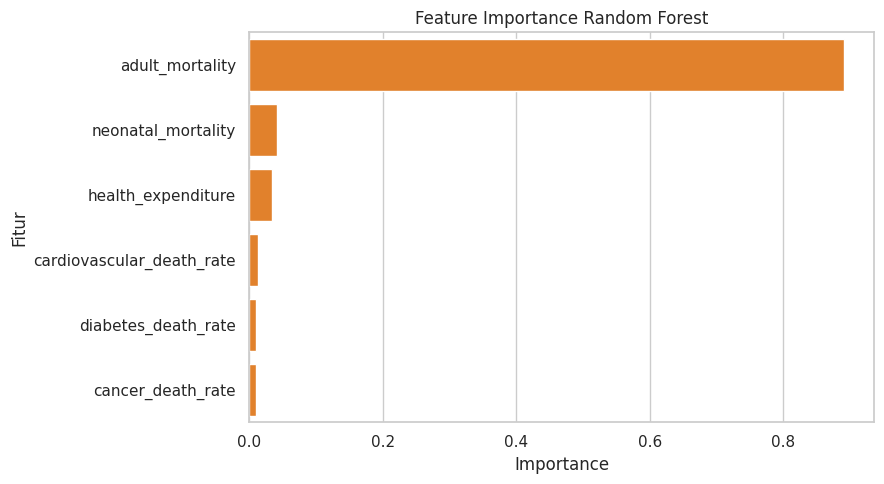

> **Insight:** Fitur paling berpengaruh adalah **adult_mortality** (importance 0.891 atau 89.1% dari total), diikuti **neonatal_mortality** (0.042). Importance menunjukkan seberapa besar fitur dipakai model untuk menurunkan error, bukan bukti sebab-akibat; fitur yang saling berkorelasi dapat membagi importance.

In [ ]:
fi = pd.DataFrame({"feature": FEATURES_ML, "importance": model.feature_importances_}).sort_values("importance", ascending=False).reset_index(drop=True)
display(fi.round(4))

fig, ax = plt.subplots(figsize=(9, 5))
sns.barplot(data=fi, x="importance", y="feature", color="tab:orange", ax=ax)
ax.set(title="Feature Importance Random Forest", xlabel="Importance", ylabel="Fitur")
plt.tight_layout(); plt.show()

RESULTS.update(top_feature=fi.loc[0, "feature"], top_importance=fi.loc[0, "importance"], fi_rank=list(fi["feature"]))
ins(f"Fitur paling berpengaruh adalah **{fi.loc[0, 'feature']}** (importance {f2(fi.loc[0, 'importance'], 3)} atau {f2(fi.loc[0, 'importance'] * 100, 1)}% dari total)"
    + (f", diikuti **{fi.loc[1, 'feature']}** ({f2(fi.loc[1, 'importance'], 3)})" if len(fi) > 1 else "")
    + ". Importance menunjukkan seberapa besar fitur dipakai model untuk menurunkan error, bukan bukti sebab-akibat; fitur yang saling berkorelasi dapat membagi importance.")

# 7. Kesimpulan

Isi kesimpulan di bawah dibuat dari angka hasil analisis di atas.

In [ ]:
def g(kunci, nd=2):
    return f2(RESULTS.get(kunci), nd)

k = []   # kumpulan baris kesimpulan
k.append("### Jawaban Business Questions\n")
k.append(f"**BQ1 (Basic).** Rata-rata angka harapan hidup berubah dari **{g('mean_first')} tahun ({RESULTS.get('first_year')})** menjadi **{g('mean_ref')} tahun ({RESULTS.get('ref_year')})** (perubahan {g('delta')} tahun). "
         f"Pada {RESULTS.get('ref_year')}, negara tertinggi adalah {RESULTS.get('top_country')} ({g('top_val')} tahun) dan terendah {RESULTS.get('bot_country')} ({g('bot_val')} tahun)."
         + (f" Region dengan rata-rata tertinggi: {RESULTS.get('best_region')} ({g('best_region_val')}), terendah: {RESULTS.get('worst_region')} ({g('worst_region_val')})." if "best_region" in RESULTS else ""))
if "r_adult" in RESULTS:
    k.append(f"\n**BQ2 (Analitis 1).** Adult mortality memiliki hubungan **{corr_desc(RESULTS['r_adult'])}** dengan angka harapan hidup (Pearson r = {g('r_adult', 3)}, Spearman = {g('rho_adult', 3)}, n = {RESULTS.get('n_adult')}).")
else:
    k.append("\n**BQ2 (Analitis 1).** Kolom adult_mortality tidak tersedia pada data sehingga tidak dapat dijawab.")
if RESULTS.get("corr_other"):
    k.append("\n**BQ3 (Analitis 2).** Korelasi Pearson indikator lain terhadap life expectancy: " +
             "; ".join([f"{nama}: {f2(v, 2)} ({corr_desc(v)})" for nama, v in RESULTS["corr_other"].items()]) + ".")
k.append(f"\n**BQ4 (AI/ML).** Random Forest (100 pohon) pada data uji ({RESULTS.get('n_test')} baris) menghasilkan MAE = {g('mae')} tahun, RMSE = {g('rmse')} tahun, R² = {g('r2', 3)} "
         f"(R² data latih = {g('r2_tr', 3)}). Fitur paling penting: **{RESULTS.get('top_feature')}** ({g('top_importance', 3)}).")

k.append("\n### Temuan Utama EDA\n")
k.append(f"* Rata-rata angka harapan hidup meningkat sebesar {g('delta')} tahun antara {RESULTS.get('first_year')} dan {RESULTS.get('ref_year')}, dan kesenjangan antar negara masih lebar (selisih tertinggi-terendah {g('gap')} tahun pada {RESULTS.get('ref_year')}).")
k.append(f"* Fitur dengan hubungan linear terkuat terhadap life expectancy: {RESULTS.get('strongest_corr_feature')} (r = {g('strongest_corr_val', 3)}).")
k.append("* Perbedaan antar region/income group (bila tersedia pada data) memperlihatkan bahwa konteks sosial-ekonomi berkaitan dengan angka harapan hidup.")

k.append("\n### Kualitas Model dan Fitur Penting\n")
k.append(f"* Urutan importance fitur: {', '.join(RESULTS.get('fi_rank', []))}.")
k.append(f"* Pada data uji temporal, rata-rata kesalahan prediksi sekitar {g('mae')} tahun; R² data uji {g('r2', 3)} dibanding {g('r2_tr', 3)} pada data latih.")

k.append("\n### Keterbatasan\n")
k.append("* Korelasi dan feature importance **bukan** bukti sebab-akibat.")
k.append("* Missing value pada indikator diimputasi dengan median (data latih), sehingga dapat meredam variasi antar negara.")
k.append("* Data uji temporal hanya mencakup tahun akhir (2020-2021 bila tersedia); periode tersebut dapat dipengaruhi kejadian khusus (misalnya pandemi) yang tidak ada pada data latih.")
k.append("* Fitur seperti adult mortality berkaitan erat secara langsung dengan angka harapan hidup, sehingga performa model yang tinggi tidak otomatis berarti model dapat dipakai untuk menentukan intervensi.")
k.append("* Tidak ada variabel sosial-ekonomi lain (pendapatan per kapita, pendidikan, sanitasi) karena hanya 4 CSV yang dipakai.")

k.append("\n### Pengembangan Selanjutnya\n")
k.append("* Menambah indikator lain (pendidikan, sanitasi, polusi, akses layanan kesehatan) dari sumber yang sama bila tersedia di database.")
k.append("* Membandingkan dengan model lain (Gradient Boosting, XGBoost, regresi regularisasi) dan melakukan *hyperparameter tuning* dengan validasi temporal (*time-series cross validation*).")
k.append("* Menggunakan *permutation importance* atau SHAP untuk interpretasi yang lebih andal, serta analisis residual per region.")

display(Markdown("\n".join(k)))

### Jawaban Business Questions

**BQ1 (Basic).** Rata-rata angka harapan hidup berubah dari **66.98 tahun (2000)** menjadi **71.29 tahun (2021)** (perubahan 4.30 tahun). Pada 2021, negara tertinggi adalah Japan (84.46 tahun) dan terendah Lesotho (51.48 tahun). Region dengan rata-rata tertinggi: North America (78.97), terendah: Sub-Saharan Africa (63.13).

**BQ2 (Analitis 1).** Adult mortality memiliki hubungan **sangat kuat dan negatif** dengan angka harapan hidup (Pearson r = -0.931, Spearman = -0.949, n = 4063).

**BQ3 (Analitis 2).** Korelasi Pearson indikator lain terhadap life expectancy: neonatal_mortality: -0.85 (sangat kuat dan negatif); health_expenditure: 0.55 (sedang dan positif); cardiovascular_death_rate: 0.28 (lemah dan positif); cancer_death_rate: 0.57 (sedang dan positif); diabetes_death_rate: -0.01 (sangat lemah dan negatif).

**BQ4 (AI/ML).** Random Forest (100 pohon) pada data uji (370 baris) menghasilkan MAE = 1.11 tahun, RMSE = 1.57 tahun, R² = 0.951 (R² data latih = 0.999). Fitur paling penting: **adult_mortality** (0.891).

### Temuan Utama EDA

* Rata-rata angka harapan hidup meningkat sebesar 4.30 tahun antara 2000 dan 2021, dan kesenjangan antar negara masih lebar (selisih tertinggi-terendah 32.98 tahun pada 2021).
* Fitur dengan hubungan linear terkuat terhadap life expectancy: adult_mortality (r = -0.931).
* Perbedaan antar region/income group (bila tersedia pada data) memperlihatkan bahwa konteks sosial-ekonomi berkaitan dengan angka harapan hidup.

### Kualitas Model dan Fitur Penting

* Urutan importance fitur: adult_mortality, neonatal_mortality, health_expenditure, cardiovascular_death_rate, diabetes_death_rate, cancer_death_rate.
* Pada data uji temporal, rata-rata kesalahan prediksi sekitar 1.11 tahun; R² data uji 0.951 dibanding 0.999 pada data latih.

### Keterbatasan

* Korelasi dan feature importance **bukan** bukti sebab-akibat.
* Missing value pada indikator diimputasi dengan median (data latih), sehingga dapat meredam variasi antar negara.
* Data uji temporal hanya mencakup tahun akhir (2020-2021 bila tersedia); periode tersebut dapat dipengaruhi kejadian khusus (misalnya pandemi) yang tidak ada pada data latih.
* Fitur seperti adult mortality berkaitan erat secara langsung dengan angka harapan hidup, sehingga performa model yang tinggi tidak otomatis berarti model dapat dipakai untuk menentukan intervensi.
* Tidak ada variabel sosial-ekonomi lain (pendapatan per kapita, pendidikan, sanitasi) karena hanya 4 CSV yang dipakai.

### Pengembangan Selanjutnya

* Menambah indikator lain (pendidikan, sanitasi, polusi, akses layanan kesehatan) dari sumber yang sama bila tersedia di database.
* Membandingkan dengan model lain (Gradient Boosting, XGBoost, regresi regularisasi) dan melakukan *hyperparameter tuning* dengan validasi temporal (*time-series cross validation*).
* Menggunakan *permutation importance* atau SHAP untuk interpretasi yang lebih andal, serta analisis residual per region.

In [ ]:
# 6.8 Simpan model untuk deployment (Streamlit)
import joblib, sklearn
from google.colab import files

paket_model = {
    "model": model,                         # Random Forest yang sudah dilatih
    "imputer": imputer,                     # median dari data latih (untuk input kosong)
    "fitur": FEATURES_ML,                   # urutan kolom fitur, harus sama saat prediksi
    "target": TARGET,                       # life_expectancy
    "median_fitur": {c: float(m) for c, m in zip(FEATURES_ML, imputer.statistics_)},
    "rentang_fitur": {c: (float(X_train[c].min()), float(X_train[c].max())) for c in FEATURES_ML},
    "metrik_uji": {"MAE": float(mae_te), "RMSE": float(rmse_te), "R2": float(r2_te)},
    "versi_sklearn": sklearn.__version__,
}

joblib.dump(paket_model, "model.pkl", compress=3)
print("model.pkl tersimpan. Fitur:", FEATURES_ML)
print("Versi scikit-learn:", sklearn.__version__)
files.download("model.pkl")

model.pkl tersimpan. Fitur: ['adult_mortality', 'neonatal_mortality', 'health_expenditure', 'cardiovascular_death_rate', 'cancer_death_rate', 'diabetes_death_rate']
Versi scikit-learn: 1.6.1


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>